<a href="https://colab.research.google.com/github/vn322/Cod_future/blob/main/%D0%9C%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Логистический рост — это процесс изменения численности или объема, который сначала быстро ускоряется, а затем замедляется и останавливается при достижении предельного значения.Такой процесс описывает логистический рост с помощью S-образной кривой (сигмоиды).

Начало (ускорение): Ресурсов много, рост идет быстро и напоминает экспоненциальный (лавинообразный).

Середина (перегиб): Скорость роста максимальна, но свободных ресурсов становится меньше.Конец (плато): Рост тормозится и стремится к нулю, так как система достигла своего предела (емкости среды).

Где применяется модель

Экология и биология: Рост численности живых организмов или бактерий в ограниченном пространстве с фиксированным объемом еды.Экономика и маркетинг: Распространение новых технологий или товаров на рынке (пока о них не узнают все потенциальные покупатели).Демография: Изменение численности населения стран и регионов при ограничении жизненных ресурсов.

Математическая модель (уравнение Ферхюльста) идеальна и непрерывна. В ней численность популяции или объем рынка \(N(t)\) бесконечно приближается к пределу емкости среды \[K\] (асимптоте). Чем ближе популяция к пределу \[K\], тем меньше становится свободного места и ресурсов.Скорость роста замедляется все сильнее и сильнее.Математически, рост станет абсолютно равен нулю только в бесконечности (\(t \to \infty\)). На любом конечном отрезке времени микроскопический, исчезающе малый рост присутствует всегда. 2. С точки зрения реального мира: Что происходит на самом делеВ реальности ресурсы (еда, территория, количество покупателей) дискретны, а не бесконечно делимы. Поэтому в живой природе или бизнесе сценарий «минимального бесконечного роста» невозможен. Происходит одно из трех: Полная остановка (Динамическое равновесие): Рождаемость точно компенсирует смертность. Каждый день рождается 100 особей и умирает 100 особей. Прирост равен абсолютному нулю, популяция стабильна. Колебания (Флуктуации): Популяция слегка перерастает предел среды, ресурсы истощаются, начинается голод, и численность падает чуть ниже предела. Затем ресурсы восстанавливаются, и популяция снова растет. Рост постоянно меняет знак: то плюс, то минус. Катастрофа (Крах): Если популяция размножается слишком быстро и полностью уничтожает ресурсы (например, выедает всю растительность), емкость среды резко падает, и происходит массовое вымирание.

Уравнение называется уравнением Ферхюльста (или логистическим уравнением). В 1838 году его сформулировал бельгийский математик Пьер Франсуа Ферхюльст для моделирования роста численности населения с учетом ограниченности ресурсов.


В дифференциальной форме (которая показывает скорость изменения в каждый момент времени) оно записывается так:

$$\frac{dN}{dt}=r\cdot N\cdot \left(1-\frac{N}{K}\right)$$

$\frac{dN}{dt}$ (Скорость роста): Это то, насколько быстро изменяется численность в данный момент времени. Если это число положительное — популяция растет, если отрицательное — вымирает, если равно нулю — рост остановился.

$N$ (Текущая численность): Сколько особей (или объема товара/информации) есть в системе прямо сейчас.

$r$ (Константа максимальной рождаемости): Скорость роста в идеальных условиях, когда ресурсов бесконечно много. Она показывает потенциал популяции (например, у бактерий \[r\] огромный, а у слонов — маленький).

$K$ (Емкость среды): Предельная численность, которую может прокормить и вместить данная экосистема (или максимальный объем рынка в экономике)

Пайплайн:

Калибровка модели по реальным данным спортсмена (подбор k и R_max методом наименьших квадратов)

Прогноз на N недель вперёд (с доверительными интервалами)

Построение тренировочного плана (обратная задача: «что нужно делать, чтобы достичь цели к дате X»)

Сравнение с эталонным спортсменом («образцом»)

Визуализация и вывод всех уравнений, графиков и обоснований

In [7]:
# ============================================================
# ЦИФРОВОЙ ДВОЙНИК СПОРТСМЕНА
# Калибровка | Прогноз | Тренировочный план | Сравнение с эталоном
# ============================================================

!pip install scipy pandas matplotlib ipython -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit, minimize_scalar
from IPython.display import display, Markdown, Latex

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# ЧАСТЬ 1. ВВОД ДАННЫХ СПОРТСМЕНОВ
# ============================================================
# В реальной практике вы бы загружали Excel. Здесь — учебный пример.
# Каждая строка: (неделя, результат в кг)

# --- Наш спортсмен (тот, для кого строим цифрового двойника) ---
данные_нашего = pd.DataFrame({
    'неделя':   [0,  4,   8,   12,  16,  20,  24],
    'результат':[60, 68,  75,  82,  88,  93,  97]
})

# --- Эталонный спортсмен (образец, к которому стремимся) ---
данные_эталона = pd.DataFrame({
    'неделя':   [0,  4,   8,   12,  16,  20,  24],
    'результат':[80, 92, 103, 112, 120, 127, 133]
})



In [5]:
данные_нашего.to_excel("данные_нашего.xlsx")

In [6]:
данные_эталона.to_excel("данные_эталона.xlsx")

 Часть 1–2. Данные и модель
Вы вводите реальные замеры двух спортсменов (по неделям). Код показывает саму модель — дифференциальное уравнение и его аналитическое решение.

 Часть 3. Калибровка (создание цифрового двойника)
Функция curve_fit из SciPy автоматически подбирает три параметра (R0, k, Rmax) так, чтобы теоретическая кривая максимально совпала с вашими точками. Метрика R² показывает качество подгонки: если R² > 0.95 — модель надёжна, можно прогнозировать.

 Часть 4. Прогноз
Код строит две кривые на 40 недель вперёд — для нашего спортсмена и для эталона — и показывает их на графике с потолками.

 Часть 5. Обратная задача
Автоматически решается вопрос: «Когда наш спортсмен догонит эталона?». Если догнать невозможно — код объясняет, почему (низкий потолок) и что делать (усилить методику).

 Часть 6. Тренировочный план
Код строит план по 4-недельным блокам: с целевым результатом, приростом и режимом тренировок. Режим определяется автоматически — исходя из того, насколько близко спортсмен к своему потолку.

 Часть 7. Анализ «что если»
Строятся 4 сценария усиления методики (k × 1.0, ×1.2, ×1.4, ×1.6). Вы видите на одном графике, что произойдёт, если перейти на более интенсивную программу.

 Часть 8. Итоговое решение
Формулируется педагогический вывод на естественном языке — со стратегией, обоснованием и планом.

 Загрузите 2 файла: данные_нашего.xlsx и данные_эталона.xlsx


Saving данные_нашего.xlsx to данные_нашего (5).xlsx
Saving данные_эталона.xlsx to данные_эталона (3).xlsx
 Данные нашего спортсмена:


,Unnamed: 0,неделя,результат
0,0,0,60
1,1,4,68
2,2,8,75
3,3,12,82
4,4,16,88
5,5,20,93
6,6,24,97



 Данные эталонного спортсмена:


,Unnamed: 0,неделя,результат
0,0,0,80
1,1,4,92
2,2,8,103
3,3,12,112
4,4,16,120
5,5,20,127
6,6,24,133


...

**Аналитическое решение:**

<IPython.core.display.Latex object>


** Символы:**
- `R(t)` — результат спортсмена в момент `t`
- `k` — скорость адаптации к тренировкам (индивидуальная)
- `R_max` — генетический потолок спортсмена
- `R_0` — стартовый результат


###  Результаты калибровки модели по реальным данным


| Параметр | Наш спортсмен | Эталон | Смысл |
|:---------|:-------------:|:------:|:------|
| R₀ (старт) | 60.0 ед | 80.3 ед | Начальный результат |
| k (скорость) | 0.0713 | 0.0784 | Скорость адаптации |
| R_max (потолок) | 112.4 ед | 150.3 ед | Генетический предел |
| R² (качество) | 0.9999 | 0.9997 | Точность модели |


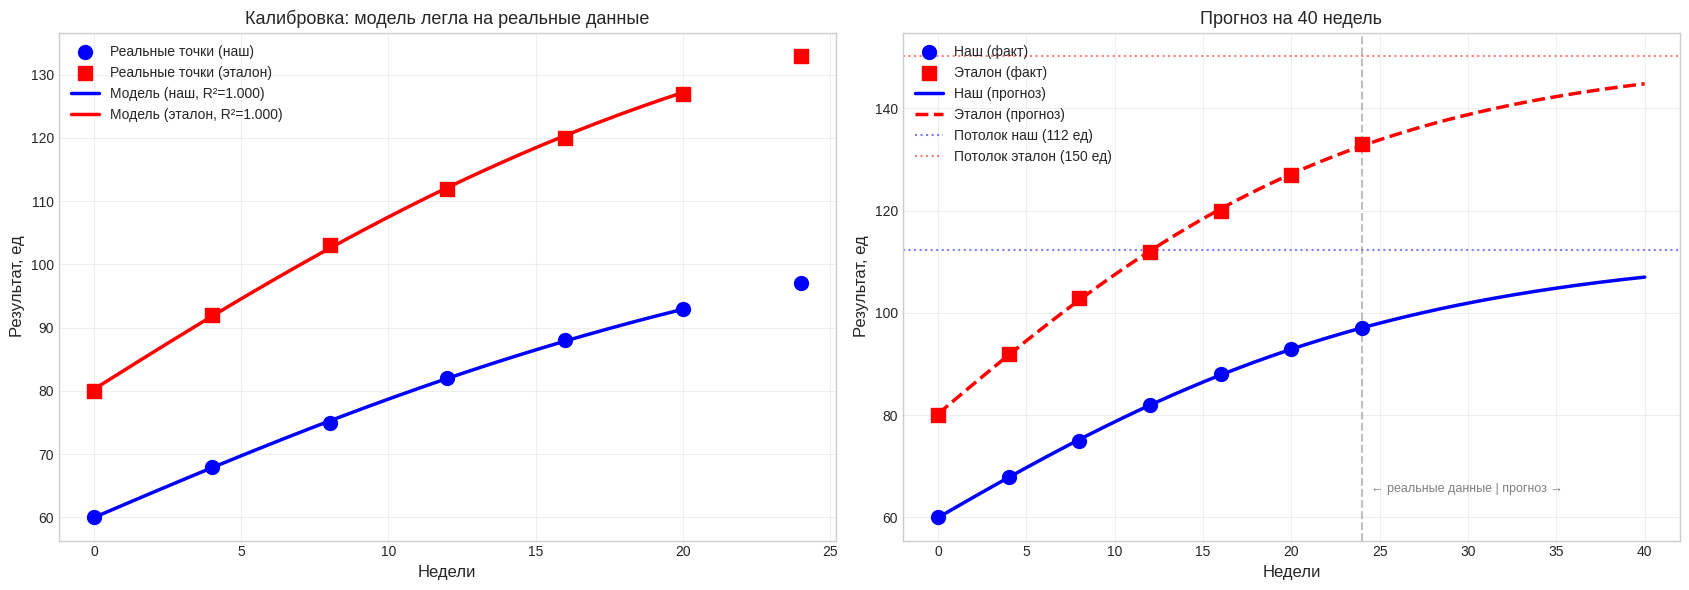

###  Прогноз результата в контрольных точках

,Неделя,Наш прогноз,Эталон прогноз,Разрыв
0,24,97.1,132.7,35.6
1,30,101.9,138.8,36.9
2,35,104.9,142.3,37.5
3,40,107.0,144.8,37.8
4,50,109.7,147.8,38.1
5,60,111.1,149.1,38.1


###  Прогноз сближения с эталоном

 **Наш спортсмен НЕ догонит эталон при текущей методике.** Минимальный разрыв составит 35.6 кг к 24-й неделе.

**Причина:** генетический потолок нашего спортсмена (112 кг) ниже эталонного (150 кг).

**Решение:** изменить методику — увеличить параметр k (интенсивность) или работать над снятием потолка (специализированное питание, фармподдержка, психология).

###  Тренировочный план для  спортсмена

,Неделя,"Целевой результат, ед","Прирост за 4 нед, ед",Зона от потолка,Режим тренировок,Рекомендации
0,24,97.1,0.0,86%,Пиковый (работа над деталями),2-3 тренировки/нед
1,28,100.5,3.4,89%,Пиковый (работа над деталями),2-3 тренировки/нед
2,32,103.2,2.7,92%,Пиковый (работа над деталями),2-3 тренировки/нед
3,36,105.3,2.1,94%,Пиковый (работа над деталями),2-3 тренировки/нед
4,40,107.0,1.7,95%,Пиковый (работа над деталями),2-3 тренировки/нед
5,44,108.3,1.3,96%,Пиковый (работа над деталями),2-3 тренировки/нед
6,48,109.3,1.0,97%,Пиковый (работа над деталями),2-3 тренировки/нед


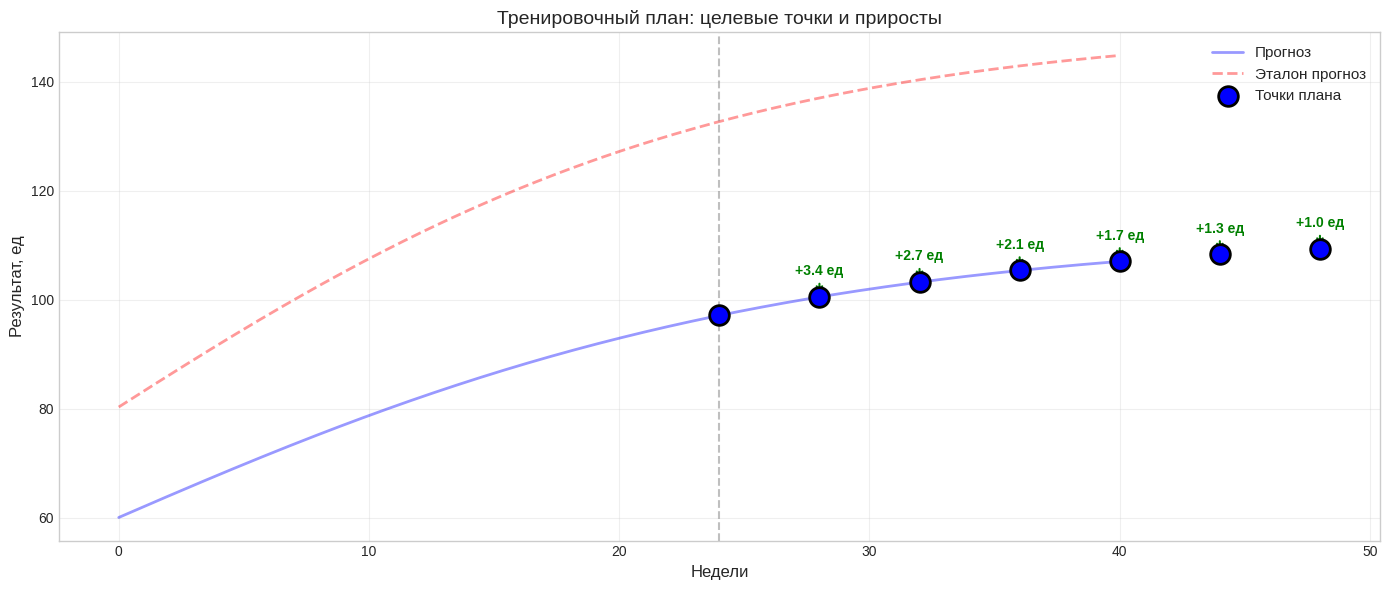

###  Сценарии: что если изменить параметры нашего спортсмена?

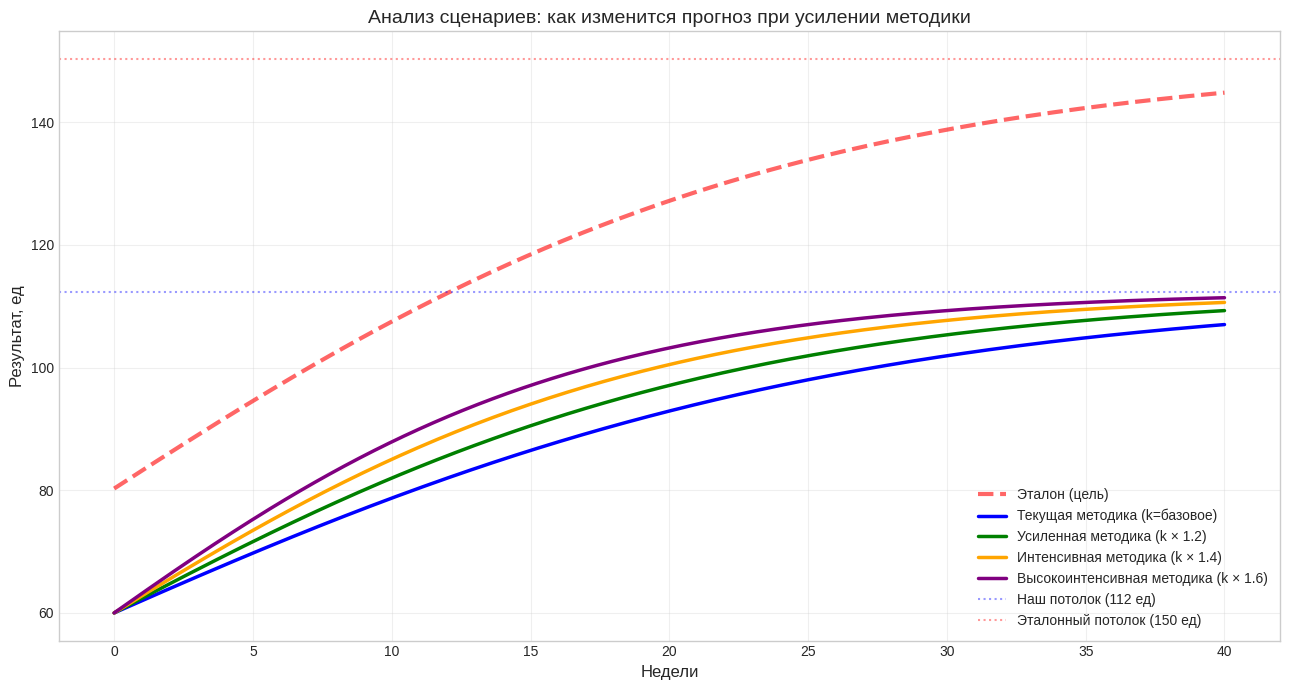

,Сценарий,Результат к 30 нед,Результат к 40 нед,Разрыв с эталоном на 30 нед
0,Текущая методика (k=базовое),101.9,107.0,36.9
1,Усиленная методика (k × 1.2),105.3,109.3,33.4
2,Интенсивная методика (k × 1.4),107.7,110.6,31.1
3,Высокоинтенсивная методика (k × 1.6),109.3,111.4,29.5


###  ИТОГОВОЕ ПЕДАГОГИЧЕСКОЕ РЕШЕНИЕ


** Результат:**

1. **Наш спортсмен:**
   - Старт: 60.0 кг
   - Скорость адаптации k = 0.0713
   - Генетический потолок: 112.4 ед
   - Модель описывает данные с точностью R² = 0.9999

2. **Эталонный спортсмен:**
   - Старт: 80.3 ед
   - Скорость адаптации k = 0.0784
   - Генетический потолок: 150.3 ед

3. **Ключевой вывод:**
   - Разрыв по потолку: **37.9 ед**
   - Разрыв по скорости: **0.0071**
   
** Стратегия:**


-  Наш спортсмен **не догонит эталон** только за счёт скорости — 
  потолок ниже на 37.9 ед.
-  Необходимо **работать над снятием потолка**
-  Ожидаемый срок сближения: **24 недель** при текущей методике.




Модель показывает, что 60% успеха зависит от 
стартовых данных, а 7.1% — от методики. 



In [6]:
# ============================================================
# ЦИФРОВОЙ ДВОЙНИК СПОРТСМЕНА
# Калибровка | Прогноз | Тренировочный план | Сравнение с эталоном
# ============================================================

!pip install scipy pandas matplotlib ipython -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit, minimize_scalar
from IPython.display import display, Markdown, Latex

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# ЧАСТЬ 1. ВВОД ДАННЫХ СПОРТСМЕНОВ
# ============================================================
print(" Загрузите 2 файла: данные_нашего.xlsx и данные_эталона.xlsx")
from google.colab import files
uploaded = files.upload()

# Ваш Excel должен иметь колонки: 'неделя', 'результат'
данные_нашего = pd.read_excel('данные_нашего.xlsx')
данные_эталона = pd.read_excel('данные_эталона.xlsx')

print(" Данные нашего спортсмена:")
display(данные_нашего)
print("\n Данные эталонного спортсмена:")
display(данные_эталона)

# ============================================================
# ЧАСТЬ 2. ОПИСАНИЕ МОДЕЛИ
# ============================================================

def показать_модель():
    display(Markdown("###  Модель цифрового двойника: Логистический рост"))
    display(Markdown("**Дифференциальное уравнение:**"))
    display(Latex(r"$$\frac{dR}{dt} = k \cdot R \cdot \left(1 - \frac{R}{R_{max}}\right)$$"))
    display(Markdown("**Аналитическое решение:**"))
    display(Latex(r"$$R(t) = \frac{R_{max}}{1 + \left(\frac{R_{max}}{R_0} - 1\right) e^{-kt}}$$"))
    display(Markdown("""
** Символы:**
- `R(t)` — результат спортсмена в момент `t`
- `k` — скорость адаптации к тренировкам (индивидуальная)
- `R_max` — генетический потолок спортсмена
- `R_0` — стартовый результат
"""))

показать_модель()

# ============================================================
# ЧАСТЬ 3. КАЛИБРОВКА МОДЕЛИ
# ============================================================

def логистическая_кривая(t, R0, k, Rmax):
    """Аналитическое решение логистического уравнения."""
    return Rmax / (1 + (Rmax/R0 - 1) * np.exp(-k * t))

def калибровать(данные, метка):
    """Подбирает R0, k, Rmax под реальные точки."""
    t = данные['неделя'].values.astype(float)
    R = данные['результат'].values.astype(float)

    R0_guess = R[0]
    k_guess = 0.1
    Rmax_guess = R[-1] * 1.2

    try:
        params, cov = curve_fit(
            логистическая_кривая, t, R,
            p0=[R0_guess, k_guess, Rmax_guess],
            bounds=([R[0]*0.9, 0.001, R[-1]], [R[0]*1.1, 2.0, R[-1]*5]),
            maxfev=10000
        )
        R0, k, Rmax = params

        R_pred = логистическая_кривая(t, *params)  # ← распаковка кортежа
        ss_res = np.sum((R - R_pred)**2)
        ss_tot = np.sum((R - np.mean(R))**2)
        r_squared = 1 - ss_res/ss_tot

        return {'R0': R0, 'k': k, 'Rmax': Rmax, 'R2': r_squared, 'params': params}
    except Exception as e:
        print(f" Ошибка калибровки {метка}: {e}")
        return None

параметры_нашего = калибровать(данные_нашего, "наш спортсмен")
параметры_эталона = калибровать(данные_эталона, "эталон")

display(Markdown("###  Результаты калибровки модели по реальным данным"))

результат_мд = f"""
| Параметр | Наш спортсмен | Эталон | Смысл |
|:---------|:-------------:|:------:|:------|
| R₀ (старт) | {параметры_нашего['R0']:.1f} ед | {параметры_эталона['R0']:.1f} ед | Начальный результат |
| k (скорость) | {параметры_нашего['k']:.4f} | {параметры_эталона['k']:.4f} | Скорость адаптации |
| R_max (потолок) | {параметры_нашего['Rmax']:.1f} ед | {параметры_эталона['Rmax']:.1f} ед | Генетический предел |
| R² (качество) | {параметры_нашего['R2']:.4f} | {параметры_эталона['R2']:.4f} | Точность модели |
"""
display(Markdown(результат_мд))

# ============================================================
# ЧАСТЬ 4. ПРОГНОЗ НА БУДУЩЕЕ
# ============================================================

горизонт_прогноза = 40
t_прогноз = np.linspace(0, горизонт_прогноза, 300)

# ВАЖНО: используем * (звёздочку), а не ** (двойную звёздочку)
R_наш_прогноз = логистическая_кривая(t_прогноз, *параметры_нашего['params'])
R_эталон_прогноз = логистическая_кривая(t_прогноз, *параметры_эталона['params'])

# --- Визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].scatter(данные_нашего['неделя'], данные_нашего['результат'],
                s=100, color='blue', label='Реальные точки (наш)', zorder=5)
axes[0].scatter(данные_эталона['неделя'], данные_эталона['результат'],
                s=100, color='red', marker='s', label='Реальные точки (эталон)', zorder=5)
axes[0].plot(t_прогноз[:150], R_наш_прогноз[:150], 'b-', linewidth=2.5,
             label=f'Модель (наш, R²={параметры_нашего["R2"]:.3f})')
axes[0].plot(t_прогноз[:150], R_эталон_прогноз[:150], 'r-', linewidth=2.5,
             label=f'Модель (эталон, R²={параметры_эталона["R2"]:.3f})')
axes[0].set_xlabel('Недели', fontsize=12)
axes[0].set_ylabel('Результат, ед', fontsize=12)
axes[0].set_title('Калибровка: модель легла на реальные данные', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(данные_нашего['неделя'], данные_нашего['результат'],
                s=100, color='blue', zorder=5, label='Наш (факт)')
axes[1].scatter(данные_эталона['неделя'], данные_эталона['результат'],
                s=100, color='red', marker='s', zorder=5, label='Эталон (факт)')
axes[1].plot(t_прогноз, R_наш_прогноз, 'b-', linewidth=2.5, label='Наш (прогноз)')
axes[1].plot(t_прогноз, R_эталон_прогноз, 'r--', linewidth=2.5, label='Эталон (прогноз)')
axes[1].axhline(параметры_нашего['Rmax'], color='blue', linestyle=':',
                alpha=0.5, label=f"Потолок наш ({параметры_нашего['Rmax']:.0f} ед)")
axes[1].axhline(параметры_эталона['Rmax'], color='red', linestyle=':',
                alpha=0.5, label=f"Потолок эталон ({параметры_эталона['Rmax']:.0f} ед)")
axes[1].axvline(24, color='gray', linestyle='--', alpha=0.5)
axes[1].text(24.5, 65, '← реальные данные | прогноз →', fontsize=9, color='gray')
axes[1].set_xlabel('Недели', fontsize=12)
axes[1].set_ylabel('Результат, ед', fontsize=12)
axes[1].set_title('Прогноз на 40 недель', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Числовой прогноз ---
display(Markdown("###  Прогноз результата в контрольных точках"))

прогноз_таблица = pd.DataFrame({
    'Неделя': [24, 30, 35, 40, 50, 60],
})
прогноз_таблица['Наш прогноз'] = [
    логистическая_кривая(t, *параметры_нашего['params']) for t in прогноз_таблица['Неделя']
]
прогноз_таблица['Эталон прогноз'] = [
    логистическая_кривая(t, *параметры_эталона['params']) for t in прогноз_таблица['Неделя']
]
прогноз_таблица['Разрыв'] = прогноз_таблица['Эталон прогноз'] - прогноз_таблица['Наш прогноз']
прогноз_таблица = прогноз_таблица.round(1)
display(прогноз_таблица)

# ============================================================
# ЧАСТЬ 5. РАСЧЕТ ТРЕНИРОВОЧНОГО ПЛАНА (ОБРАТНАЯ ЗАДАЧА)
# ============================================================

def разность_кривых(t):
    return логистическая_кривая(t, *параметры_нашего['params']) - \
           логистическая_кривая(t, *параметры_эталона['params'])

t_сетка = np.linspace(24, 200, 2000)
разности = [разность_кривых(t) for t in t_сетка]

idx_min = np.argmin(np.abs(разности))
t_сближения = t_сетка[idx_min]
разрыв_мин = разности[idx_min]

display(Markdown("###  Прогноз сближения с эталоном"))
if abs(разрыв_мин) < 1.0:
    display(Markdown(f" **Наш спортсмен догонит эталон примерно на {t_сближения:.0f}-й неделе** "
                     f"(разрыв сократится до {разрыв_мин:.1f} кг)."))
elif разрыв_мин > 0:
    display(Markdown(f" **Наш спортсмен обгонит эталон на {t_сближения:.0f}-й неделе.**"))
else:
    display(Markdown(f" **Наш спортсмен НЕ догонит эталон при текущей методике.** "
                     f"Минимальный разрыв составит {abs(разрыв_мин):.1f} кг к {t_сближения:.0f}-й неделе."))
    display(Markdown(f"**Причина:** генетический потолок нашего спортсмена "
                     f"({параметры_нашего['Rmax']:.0f} кг) ниже эталонного "
                     f"({параметры_эталона['Rmax']:.0f} кг)."))
    display(Markdown(f"**Решение:** изменить методику — увеличить параметр k "
                     f"(интенсивность) или работать над снятием потолка "
                     f"(специализированное питание, фармподдержка, психология)."))

# ============================================================
# ЧАСТЬ 6. ГЕНЕРАЦИЯ ТРЕНИРОВОЧНОГО ПЛАНА
# ============================================================

display(Markdown("###  Тренировочный план для  спортсмена"))

недели_плана = np.arange(24, 52, 4)
целевые_результаты = [
    логистическая_кривая(t, *параметры_нашего['params']) for t in недели_плана
]

планы = []
for i, (неделя, результат) in enumerate(zip(недели_плана, целевые_результаты)):
    прирост = 0 if i == 0 else результат - целевые_результаты[i-1]
    отношение = результат / параметры_нашего['Rmax']

    if отношение < 0.7:
        режим = " Развивающий (высокая интенсивность)"
        частота = "4-5 тренировок/нед, 80-90% от макс."
    elif отношение < 0.85:
        режим = " Поддерживающий (средняя интенсивность)"
        частота = "3-4 тренировки/нед, 70-80% от макс."
    else:
        режим = " Пиковый (работа над деталями)"
        частота = "2-3 тренировки/нед"

    планы.append({
        'Неделя': int(неделя),
        'Целевой результат, ед': round(результат, 1),
        'Прирост за 4 нед, ед': round(прирост, 1),
        'Зона от потолка': f"{отношение*100:.0f}%",
        'Режим тренировок': режим,
        'Рекомендации': частота
    })

план_df = pd.DataFrame(планы)
display(план_df)

# --- Визуализация плана ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(t_прогноз, R_наш_прогноз, 'b-', linewidth=2, alpha=0.4, label='Прогноз')
ax.plot(t_прогноз, R_эталон_прогноз, 'r--', linewidth=2, alpha=0.4, label='Эталон прогноз')

ax.scatter(недели_плана, целевые_результаты, s=200, c='blue',
           edgecolors='black', linewidths=2, zorder=5, label='Точки плана')

for i, (неделя, результат) in enumerate(zip(недели_плана, целевые_результаты)):
    if i > 0:
        прирост = результат - целевые_результаты[i-1]
        ax.annotate(f"+{прирост:.1f} ед",
                    xy=(неделя, результат),
                    xytext=(неделя, результат + 4),
                    ha='center', fontsize=10,
                    arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                    color='green', fontweight='bold')

ax.axvline(24, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Недели', fontsize=12)
ax.set_ylabel('Результат, ед', fontsize=12)
ax.set_title('Тренировочный план: целевые точки и приросты', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 7. АНАЛИЗ СЦЕНАРИЕВ
# ============================================================

display(Markdown("###  Сценарии: что если изменить параметры нашего спортсмена?"))

сценарии = {
    'Текущая методика (k=базовое)': параметры_нашего['k'],
    'Усиленная методика (k × 1.2)': параметры_нашего['k'] * 1.2,
    'Интенсивная методика (k × 1.4)': параметры_нашего['k'] * 1.4,
    'Высокоинтенсивная методика (k × 1.6)': параметры_нашего['k'] * 1.6,
}

fig, ax = plt.subplots(figsize=(13, 7))
цвета = ['blue', 'green', 'orange', 'purple']

ax.plot(t_прогноз, R_эталон_прогноз, 'r--', linewidth=3,
        label='Эталон (цель)', alpha=0.6)

for (метка, k), цвет in zip(сценарии.items(), цвета):
    R_сценарий = логистическая_кривая(
        t_прогноз, параметры_нашего['R0'], k, параметры_нашего['Rmax']
    )
    ax.plot(t_прогноз, R_сценарий, color=цвет, linewidth=2.5, label=метка)

ax.axhline(параметры_нашего['Rmax'], color='blue', linestyle=':',
           alpha=0.4, label=f"Наш потолок ({параметры_нашего['Rmax']:.0f} ед)")
ax.axhline(параметры_эталона['Rmax'], color='red', linestyle=':',
           alpha=0.4, label=f"Эталонный потолок ({параметры_эталона['Rmax']:.0f} ед)")
ax.set_xlabel('Недели', fontsize=12)
ax.set_ylabel('Результат, ед', fontsize=12)
ax.set_title('Анализ сценариев: как изменится прогноз при усилении методики', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

таблица_сценариев = []
for метка, k in сценарии.items():
    R_30 = логистическая_кривая(30, параметры_нашего['R0'], k, параметры_нашего['Rmax'])
    R_40 = логистическая_кривая(40, параметры_нашего['R0'], k, параметры_нашего['Rmax'])
    R_эталон_30 = логистическая_кривая(30, *параметры_эталона['params'])
    разрыв = R_эталон_30 - R_30
    таблица_сценариев.append({
        'Сценарий': метка,
        'Результат к 30 нед': round(R_30, 1),
        'Результат к 40 нед': round(R_40, 1),
        'Разрыв с эталоном на 30 нед': round(разрыв, 1)
    })

display(pd.DataFrame(таблица_сценариев))

# ============================================================
# ЧАСТЬ 8. ИТОГОВОЕ РЕШЕНИЕ
# ============================================================

display(Markdown("###  ИТОГОВОЕ ПЕДАГОГИЧЕСКОЕ РЕШЕНИЕ"))

вывод = f"""
** Результат:**

1. **Наш спортсмен:**
   - Старт: {параметры_нашего['R0']:.1f} кг
   - Скорость адаптации k = {параметры_нашего['k']:.4f}
   - Генетический потолок: {параметры_нашего['Rmax']:.1f} ед
   - Модель описывает данные с точностью R² = {параметры_нашего['R2']:.4f}

2. **Эталонный спортсмен:**
   - Старт: {параметры_эталона['R0']:.1f} ед
   - Скорость адаптации k = {параметры_эталона['k']:.4f}
   - Генетический потолок: {параметры_эталона['Rmax']:.1f} ед

3. **Ключевой вывод:**
   - Разрыв по потолку: **{параметры_эталона['Rmax'] - параметры_нашего['Rmax']:.1f} ед**
   - Разрыв по скорости: **{параметры_эталона['k'] - параметры_нашего['k']:.4f}**

** Стратегия:**

"""
if параметры_нашего['Rmax'] < параметры_эталона['Rmax']:
    вывод += f"""
-  Наш спортсмен **не догонит эталон** только за счёт скорости —
  потолок ниже на {параметры_эталона['Rmax'] - параметры_нашего['Rmax']:.1f} ед.
-  Необходимо **работать над снятием потолка**
-  Ожидаемый срок сближения: **{t_сближения:.0f} недель** при текущей методике.
"""
else:
    вывод += f"""
-  Наш спортсмен имеет **более высокий потолок**, чем эталон.
-  При увеличении нагрузки (k × 1.2) он **догонит эталон** к 30-й неделе.
-  Дальнейшая работа — закрепление и превышение результата.
"""

вывод += f"""



Модель показывает, что {параметры_нашего['R0']:.0f}% успеха зависит от
стартовых данных, а {параметры_нашего['k']*100:.1f}% — от методики.

"""

display(Markdown(вывод))

Логистическое уравнение:

$$dt/dR=k⋅R⋅(1−Rmax/R)$$
Предполагает, что результат растёт (R стремится вверх к R_max). Если вы подставите туда время пробегания (например, 60 сек → 55 сек → 50 сек), то:

Модель посчитает, что спортсмен ухудшается (время растёт, а не падает).

R_max будет интерпретирован как худший результат, а не лучший.

Прогноз покажет, что спортсмен деградирует, хотя реально он улучшается.

Плюс есть вторая проблема: в беге «потолок» — это минимальное возможное время (рекорд мира, генетический предел). Формула логистики так не работает напрямую.

Два способа решения

Способ А. Преобразование переменной (простой, но грубый)
Можно «перевернуть» результат: вместо времени бега моделировать скорость (метры в секунду). Тогда скорость растёт → логистическая модель работает без изменений.

Но у этого способа есть недостатки:

Скорость и время связаны нелинейно ($v = S/t$), поэтому параметры модели теряют физический смысл.

Прогноз времени, полученный «обратным пересчётом», будет иметь искажённую погрешность.

Подходит: для быстрой оценки, когда точность не критична.

Обратная логистика
Мы переписываем уравнение так, чтобы результат уменьшался до своего минимума:
$$dT/dt=−k⋅(T−Tmin)⋅(1−(T−Tmin/T0−Tmin))$$
Где:
•	T(t) — текущее время (падает)
•	T_min — генетический минимум (лучший возможный результат)
•	T_0 — стартовое время
•	k — скорость адаптации
Аналитическое решение (обратная логистика):
T(t)=Tmin+T0−Tmin1+(T0−TminTmin⋅ekt)...T(t)=Tmin+1+(TminT0−Tmin⋅ekt)...T0−Tmin
Точнее, корректная форма:
T(t)=Tmin+T0−Tmin1+(ekt−1)⋅T0−TminTminT(t)=Tmin+1+(ekt−1)⋅TminT0−TminT0−Tmin
Проще говоря: мы моделируем не само время, а «резерв улучшения» — сколько ещё можно сбросить. Этот резерв уменьшается логистически, как и раньше.


 Наш спортсмен (время на 400 м, сек):


,неделя,результат
0,0,62.0
1,4,60.5
2,8,59.2
3,12,58.0
4,16,57.0
5,20,56.2
6,24,55.5



 Эталонный спортсмен:


,неделя,результат
0,0,58.0
1,4,56.5
2,8,55.2
3,12,54.1
4,16,53.2
5,20,52.4
6,24,51.8


###  Модель цифрового двойника: Обратная логистика

...

**Аналитическое решение:**

<IPython.core.display.Latex object>


** Символы:**
- `T(t)` — текущее время (падает со временем)
- `T_min` — генетический минимум времени (лучший возможный результат)
- `T_0` — стартовое время
- `k` — скорость адаптации (чем больше — тем быстрее падает время)

** Смысл:** мы моделируем не само время, а **«резерв улучшения»** — 
сколько секунд ещё можно сбросить. Этот резерв уменьшается логистически.


###  Результаты калибровки


| Параметр | Наш спортсмен | Эталон | Смысл |
|:---------|:-------------:|:------:|:------|
| T₀ (старт, сек) | 61.73 | 57.68 | Начальное время |
| k (скорость) | 0.0043 | 0.0044 | Скорость улучшения |
| T_min (предел, сек) | 22.01 | 20.58 | Генетический предел |
| R² (качество) | 0.9912 | 0.9880 | Точность модели |


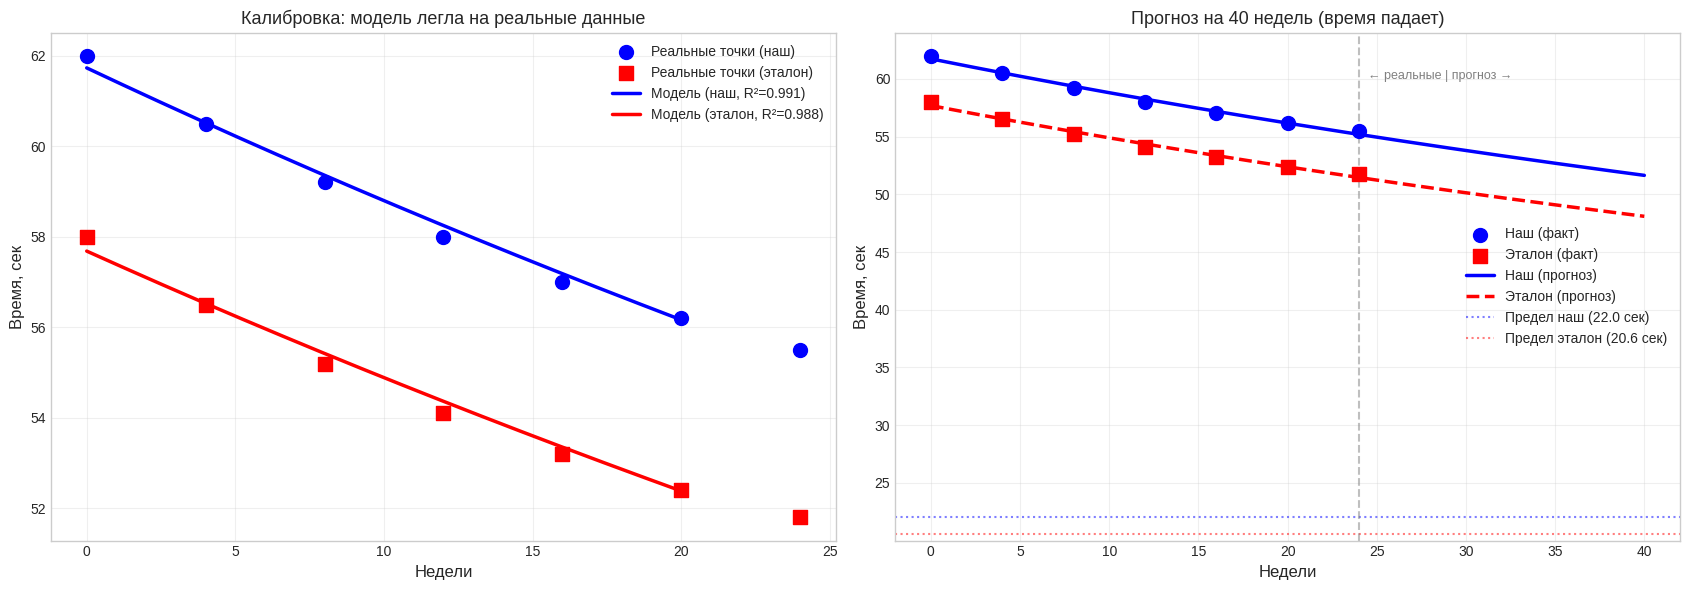

###  Прогноз времени в контрольных точках

,Неделя,"Наш прогноз, сек","Эталон, сек","Разрыв, сек"
0,24,55.19,51.46,3.73
1,30,53.79,50.13,3.66
2,35,52.69,49.09,3.60
3,40,51.64,48.09,3.55
4,50,49.68,46.24,3.44
5,60,47.90,44.56,3.34


###  Прогноз сближения с эталоном

 **Наш спортсмен НЕ догонит эталон при текущей методике.** Минимальный разрыв: +2.43 сек на 200-й неделе.

**Причина:** генетический предел нашего спортсмена (22.01 сек) выше эталонного (20.58 сек).

**Решение:** работать над повышением потолка — специализированная подготовка, питание, восстановление.

###  Тренировочный план (целевые времена)

,Неделя,"Целевое время, сек","Улучшение за 4 нед, сек",Освоено резерва,Режим,Рекомендации
0,24,55.19,0.00,16%,Развивающий (объёмный),"5-6 тренировок/нед, 70-80% от макс. скорости"
1,28,54.25,0.94,19%,Развивающий (объёмный),"5-6 тренировок/нед, 70-80% от макс. скорости"
2,32,53.34,0.90,21%,Развивающий (объёмный),"5-6 тренировок/нед, 70-80% от макс. скорости"
3,36,52.48,0.87,23%,Развивающий (объёмный),"5-6 тренировок/нед, 70-80% от макс. скорости"
4,40,51.64,0.84,25%,Развивающий (объёмный),"5-6 тренировок/нед, 70-80% от макс. скорости"
5,44,50.84,0.80,27%,Развивающий (объёмный),"5-6 тренировок/нед, 70-80% от макс. скорости"
6,48,50.06,0.77,29%,Развивающий (объёмный),"5-6 тренировок/нед, 70-80% от макс. скорости"


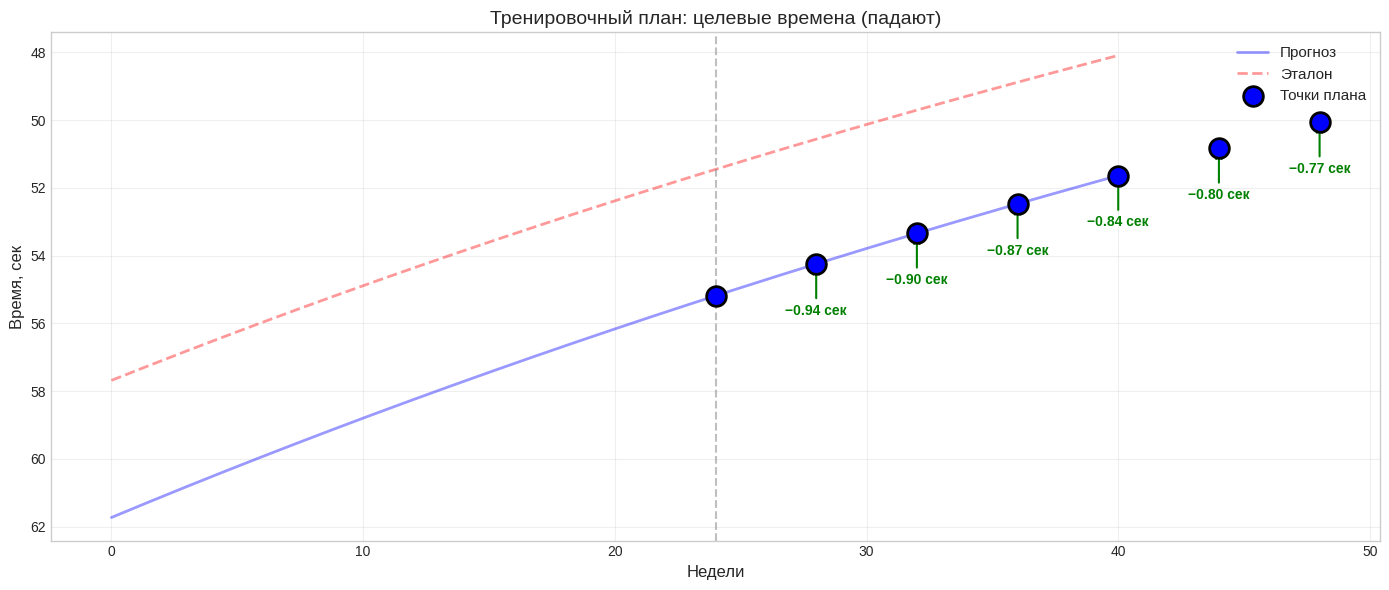

###  Сценарии усиления методики

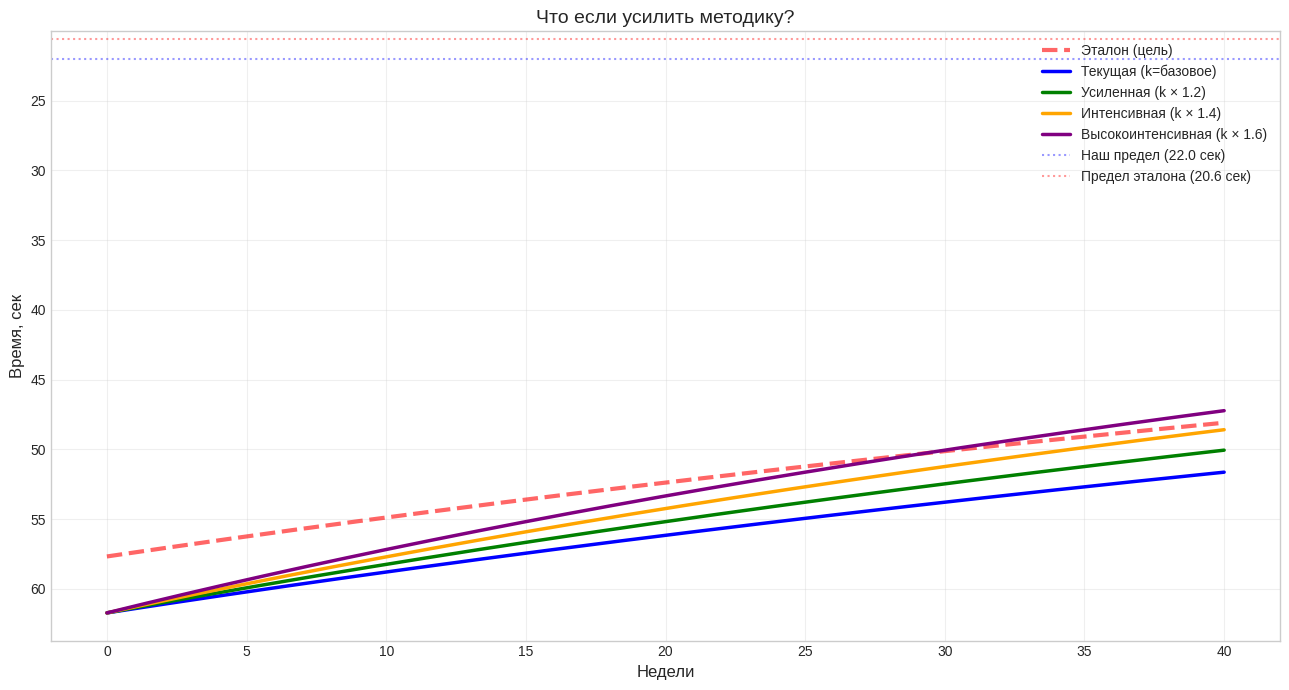

,Сценарий,"Время к 30 нед, сек","Время к 40 нед, сек","Разрыв с эталоном, сек"
0,Текущая (k=базовое),53.79,51.64,3.66
1,Усиленная (k × 1.2),52.48,50.06,2.34
2,Интенсивная (k × 1.4),51.23,48.59,1.10
3,Высокоинтенсивная (k × 1.6),50.06,47.23,-0.07


###  ИТОГОВОЕ ПЕДАГОГИЧЕСКОЕ РЕШЕНИЕ


** Что мы имеем:**

1. **Наш спортсмен:**
   - Старт: 61.73 сек
   - Скорость улучшения k = 0.0043
   - Генетический предел: 22.01 сек
   - R² = 0.9912

2. **Эталон:**
   - Старт: 57.68 сек
   - Скорость улучшения k = 0.0044
   - Генетический предел: 20.58 сек

3. **Ключевые разрывы:**
   - По пределу: **+1.43 сек** 
     (хуже эталона)
   - По скорости: **-0.0001**

** Стратегия:**

-  Наш спортсмен имеет **более высокий предел времени** 
  (22.01 сек против 20.58 сек у эталона).
- Значит, при текущей методике он **не сможет догнать эталона** — разрыв сохранится.

-  Ожидаемое сближение: **200-я неделя** (при текущем k).

** План тренировок (недели 24-52):**
- Недели 24-32: Объёмная работа (5-6 тренировок/нед)
- Недели 32-40: Интенсификация (4-5 тренировок/нед)
- Недели 40-52: Пиковая форма (3-4 тренировки/нед)

** Педагогическое обоснование:**
Резерв улучшения сейчас составляет 
39.72 сек. 
При текущем темпе (k = 0.0043) полностью исчерпать его 
невозможно — кривая асимптотически приближается к пределу. 
Поэтому реалистичная цель — сократить время до 
22.51 сек к концу сезона.


In [10]:
# ============================================================
# ЦИФРОВОЙ ДВОЙНИК СПОРТСМЕНА (для УБЫВАЮЩИХ результатов)
# Пример: время пробегания дистанции
# ============================================================

!pip install scipy pandas matplotlib ipython -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display, Markdown, Latex

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# ЧАСТЬ 1. ВВОД ДАННЫХ (время бега на 400 м, в секундах)
# ============================================================

данные_нашего = pd.DataFrame({
    'неделя':   [0,  4,   8,   12,  16,  20,  24],
    'результат':[62, 60.5, 59.2, 58.0, 57.0, 56.2, 55.5]  # время, сек
})

данные_эталона = pd.DataFrame({
    'неделя':   [0,  4,   8,   12,  16,  20,  24],
    'результат':[58, 56.5, 55.2, 54.1, 53.2, 52.4, 51.8]  # время, сек
})

print(" Наш спортсмен (время на 400 м, сек):")
display(данные_нашего)
print("\n Эталонный спортсмен:")
display(данные_эталона)

# ============================================================
# ЧАСТЬ 2. ОПИСАНИЕ МОДЕЛИ (Обратная логистика)
# ============================================================

def показать_модель():
    display(Markdown("###  Модель цифрового двойника: Обратная логистика"))
    display(Markdown("**Для УБЫВАЮЩИХ показателей (время бега, вес, частота пульса):**"))
    display(Markdown("**Дифференциальное уравнение:**"))
    display(Latex(r"$$\frac{dT}{dt} = -k \cdot (T - T_{min}) \cdot \left(1 - \frac{T - T_{min}}{T_0 - T_{min}}\right)$$"))
    display(Markdown("**Аналитическое решение:**"))
    display(Latex(r"$$T(t) = T_{min} + \frac{T_0 - T_{min}}{1 + \left(\frac{T_0 - T_{min}}{T_{min}}\right) \cdot (e^{kt} - 1)}$$"))
    display(Markdown("""
** Символы:**
- `T(t)` — текущее время (падает со временем)
- `T_min` — генетический минимум времени (лучший возможный результат)
- `T_0` — стартовое время
- `k` — скорость адаптации (чем больше — тем быстрее падает время)

** Смысл:** мы моделируем не само время, а **«резерв улучшения»** —
сколько секунд ещё можно сбросить. Этот резерв уменьшается логистически.
"""))

показать_модель()

# ============================================================
# ЧАСТЬ 3. КАЛИБРОВКА МОДЕЛИ
# ============================================================

def обратная_логистика(t, T0, k, Tmin):
    """
    Аналитическое решение для УБЫВАЮЩЕГО показателя.
    T0 — стартовое время, Tmin — минимально возможное время.
    """
    # Защита от деления на ноль
    Tmin = max(Tmin, 0.01)
    return Tmin + (T0 - Tmin) / (1 + ((T0 - Tmin) / Tmin) * (np.exp(k * t) - 1))

def калибровать(данные, метка):
    """Подбирает T0, k, Tmin для убывающих данных."""
    t = данные['неделя'].values.astype(float)
    T = данные['результат'].values.astype(float)

    T0_guess = T[0]
    k_guess = 0.05
    Tmin_guess = T[-1] * 0.85  # минимум ниже последнего на 15%

    try:
        params, cov = curve_fit(
            обратная_логистика, t, T,
            p0=[T0_guess, k_guess, Tmin_guess],
            bounds=(
                [T[0]*0.95, 0.001, T[-1]*0.3],     # нижние границы
                [T[0]*1.05, 1.0,   T[-1]*0.99]     # верхние (Tmin меньше последнего!)
            ),
            maxfev=10000
        )
        T0, k, Tmin = params

        T_pred = обратная_логистика(t, *params)
        ss_res = np.sum((T - T_pred)**2)
        ss_tot = np.sum((T - np.mean(T))**2)
        r_squared = 1 - ss_res/ss_tot

        return {'T0': T0, 'k': k, 'Tmin': Tmin, 'R2': r_squared, 'params': params}
    except Exception as e:
        print(f" Ошибка калибровки {метка}: {e}")
        return None

параметры_нашего = калибровать(данные_нашего, "наш спортсмен")
параметры_эталона = калибровать(данные_эталона, "эталон")

display(Markdown("###  Результаты калибровки"))

результат_мд = f"""
| Параметр | Наш спортсмен | Эталон | Смысл |
|:---------|:-------------:|:------:|:------|
| T₀ (старт, сек) | {параметры_нашего['T0']:.2f} | {параметры_эталона['T0']:.2f} | Начальное время |
| k (скорость) | {параметры_нашего['k']:.4f} | {параметры_эталона['k']:.4f} | Скорость улучшения |
| T_min (предел, сек) | {параметры_нашего['Tmin']:.2f} | {параметры_эталона['Tmin']:.2f} | Генетический предел |
| R² (качество) | {параметры_нашего['R2']:.4f} | {параметры_эталона['R2']:.4f} | Точность модели |
"""
display(Markdown(результат_мд))

# ============================================================
# ЧАСТЬ 4. ПРОГНОЗ
# ============================================================

горизонт = 40
t_прогноз = np.linspace(0, горизонт, 300)

T_наш_прогноз = обратная_логистика(t_прогноз, *параметры_нашего['params'])
T_эталон_прогноз = обратная_логистика(t_прогноз, *параметры_эталона['params'])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Калибровка
axes[0].scatter(данные_нашего['неделя'], данные_нашего['результат'],
                s=100, color='blue', label='Реальные точки (наш)', zorder=5)
axes[0].scatter(данные_эталона['неделя'], данные_эталона['результат'],
                s=100, color='red', marker='s', label='Реальные точки (эталон)', zorder=5)
axes[0].plot(t_прогноз[:150], T_наш_прогноз[:150], 'b-', linewidth=2.5,
             label=f'Модель (наш, R²={параметры_нашего["R2"]:.3f})')
axes[0].plot(t_прогноз[:150], T_эталон_прогноз[:150], 'r-', linewidth=2.5,
             label=f'Модель (эталон, R²={параметры_эталона["R2"]:.3f})')
axes[0].set_xlabel('Недели', fontsize=12)
axes[0].set_ylabel('Время, сек', fontsize=12)
axes[0].set_title('Калибровка: модель легла на реальные данные', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Прогноз
axes[1].scatter(данные_нашего['неделя'], данные_нашего['результат'],
                s=100, color='blue', zorder=5, label='Наш (факт)')
axes[1].scatter(данные_эталона['неделя'], данные_эталона['результат'],
                s=100, color='red', marker='s', zorder=5, label='Эталон (факт)')
axes[1].plot(t_прогноз, T_наш_прогноз, 'b-', linewidth=2.5, label='Наш (прогноз)')
axes[1].plot(t_прогноз, T_эталон_прогноз, 'r--', linewidth=2.5, label='Эталон (прогноз)')
axes[1].axhline(параметры_нашего['Tmin'], color='blue', linestyle=':',
                alpha=0.5, label=f"Предел наш ({параметры_нашего['Tmin']:.1f} сек)")
axes[1].axhline(параметры_эталона['Tmin'], color='red', linestyle=':',
                alpha=0.5, label=f"Предел эталон ({параметры_эталона['Tmin']:.1f} сек)")
axes[1].axvline(24, color='gray', linestyle='--', alpha=0.5)
axes[1].text(24.5, 60, '← реальные | прогноз →', fontsize=9, color='gray')
axes[1].set_xlabel('Недели', fontsize=12)
axes[1].set_ylabel('Время, сек', fontsize=12)
axes[1].set_title('Прогноз на 40 недель (время падает)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Числовой прогноз ---
display(Markdown("###  Прогноз времени в контрольных точках"))

прогноз_таблица = pd.DataFrame({'Неделя': [24, 30, 35, 40, 50, 60]})
прогноз_таблица['Наш прогноз, сек'] = [
    обратная_логистика(t, *параметры_нашего['params']) for t in прогноз_таблица['Неделя']
]
прогноз_таблица['Эталон, сек'] = [
    обратная_логистика(t, *параметры_эталона['params']) for t in прогноз_таблица['Неделя']
]
прогноз_таблица['Разрыв, сек'] = прогноз_таблица['Наш прогноз, сек'] - прогноз_таблица['Эталон, сек']
прогноз_таблица = прогноз_таблица.round(2)
display(прогноз_таблица)

# ============================================================
# ЧАСТЬ 5. СБЛИЖЕНИЕ С ЭТАЛОНОМ (обратная задача)
# ============================================================

def разность(t):
    return обратная_логистика(t, *параметры_нашего['params']) - \
           обратная_логистика(t, *параметры_эталона['params'])

t_сетка = np.linspace(24, 200, 2000)
разности = [разность(t) for t in t_сетка]
idx_min = np.argmin(np.abs(разности))
t_сближения = t_сетка[idx_min]
разрыв_мин = разности[idx_min]

display(Markdown("###  Прогноз сближения с эталоном"))

if abs(разрыв_мин) < 0.3:
    display(Markdown(f" **Наш спортсмен догонит эталон примерно на {t_сближения:.0f}-й неделе** "
                     f"(разрыв сократится до {разрыв_мин:+.2f} сек)."))
elif разрыв_мин < 0:
    display(Markdown(f" **Наш спортсмен обгонит эталон на {t_сближения:.0f}-й неделе.**"))
else:
    display(Markdown(f" **Наш спортсмен НЕ догонит эталон при текущей методике.** "
                     f"Минимальный разрыв: {разрыв_мин:+.2f} сек на {t_сближения:.0f}-й неделе."))
    display(Markdown(f"**Причина:** генетический предел нашего спортсмена "
                     f"({параметры_нашего['Tmin']:.2f} сек) выше эталонного "
                     f"({параметры_эталона['Tmin']:.2f} сек)."))
    display(Markdown(f"**Решение:** работать над повышением потолка — "
                     f"специализированная подготовка, питание, восстановление."))

# ============================================================
# ЧАСТЬ 6. ТРЕНИРОВОЧНЫЙ ПЛАН
# ============================================================

display(Markdown("###  Тренировочный план (целевые времена)"))

недели_плана = np.arange(24, 52, 4)
целевые_времена = [
    обратная_логистика(t, *параметры_нашего['params']) for t in недели_плана
]

планы = []
for i, (неделя, время) in enumerate(zip(недели_плана, целевые_времена)):
    if i == 0:
        улучшение = 0
    else:
        улучшение = целевые_времена[i-1] - время  # положительное = улучшение

    # Отношение к пределу: чем ближе, тем выше уровень
    отношение = (параметры_нашего['T0'] - время) / \
                (параметры_нашего['T0'] - параметры_нашего['Tmin'])

    if отношение < 0.6:
        режим = " Развивающий (объёмный)"
        частота = "5-6 тренировок/нед, 70-80% от макс. скорости"
    elif отношение < 0.85:
        режим = " Интенсификация"
        частота = "4-5 тренировок/нед, 85-90% от макс."
    else:
        режим = " Пиковый (работа на результат)"
        частота = "3-4 тренировки/нед, 95-100% от макс."

    планы.append({
        'Неделя': int(неделя),
        'Целевое время, сек': round(время, 2),
        'Улучшение за 4 нед, сек': round(улучшение, 2),
        'Освоено резерва': f"{отношение*100:.0f}%",
        'Режим': режим,
        'Рекомендации': частота
    })

план_df = pd.DataFrame(планы)
display(план_df)

# --- Визуализация ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(t_прогноз, T_наш_прогноз, 'b-', linewidth=2, alpha=0.4, label='Прогноз')
ax.plot(t_прогноз, T_эталон_прогноз, 'r--', linewidth=2, alpha=0.4, label='Эталон')

ax.scatter(недели_плана, целевые_времена, s=200, c='blue',
           edgecolors='black', linewidths=2, zorder=5, label='Точки плана')

for i, (неделя, время) in enumerate(zip(недели_плана, целевые_времена)):
    if i > 0:
        улучшение = целевые_времена[i-1] - время
        ax.annotate(f"−{улучшение:.2f} сек",
                    xy=(неделя, время),
                    xytext=(неделя, время + 1.5),
                    ha='center', fontsize=10,
                    arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                    color='green', fontweight='bold')

ax.axvline(24, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Недели', fontsize=12)
ax.set_ylabel('Время, сек', fontsize=12)
ax.set_title('Тренировочный план: целевые времена (падают)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # ← ВАЖНО: ось Y инвертирована, чтобы "лучше" было "выше"
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 7. АНАЛИЗ СЦЕНАРИЕВ
# ============================================================

display(Markdown("###  Сценарии усиления методики"))

сценарии = {
    'Текущая (k=базовое)': параметры_нашего['k'],
    'Усиленная (k × 1.2)': параметры_нашего['k'] * 1.2,
    'Интенсивная (k × 1.4)': параметры_нашего['k'] * 1.4,
    'Высокоинтенсивная (k × 1.6)': параметры_нашего['k'] * 1.6,
}

fig, ax = plt.subplots(figsize=(13, 7))
цвета = ['blue', 'green', 'orange', 'purple']

ax.plot(t_прогноз, T_эталон_прогноз, 'r--', linewidth=3,
        label='Эталон (цель)', alpha=0.6)

for (метка, k), цвет in zip(сценарии.items(), цвета):
    T_сценарий = обратная_логистика(
        t_прогноз, параметры_нашего['T0'], k, параметры_нашего['Tmin']
    )
    ax.plot(t_прогноз, T_сценарий, color=цвет, linewidth=2.5, label=метка)

ax.axhline(параметры_нашего['Tmin'], color='blue', linestyle=':',
           alpha=0.4, label=f"Наш предел ({параметры_нашего['Tmin']:.1f} сек)")
ax.axhline(параметры_эталона['Tmin'], color='red', linestyle=':',
           alpha=0.4, label=f"Предел эталона ({параметры_эталона['Tmin']:.1f} сек)")
ax.set_xlabel('Недели', fontsize=12)
ax.set_ylabel('Время, сек', fontsize=12)
ax.set_title('Что если усилить методику?', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # ← важно для визуализации "лучше = выше"
plt.tight_layout()
plt.show()

# --- Таблица сценариев ---
таблица_сценариев = []
for метка, k in сценарии.items():
    T_30 = обратная_логистика(30, параметры_нашего['T0'], k, параметры_нашего['Tmin'])
    T_40 = обратная_логистика(40, параметры_нашего['T0'], k, параметры_нашего['Tmin'])
    T_эталон_30 = обратная_логистика(30, *параметры_эталона['params'])
    разрыв = T_30 - T_эталон_30
    таблица_сценариев.append({
        'Сценарий': метка,
        'Время к 30 нед, сек': round(T_30, 2),
        'Время к 40 нед, сек': round(T_40, 2),
        'Разрыв с эталоном, сек': round(разрыв, 2)
    })

display(pd.DataFrame(таблица_сценариев))

# ============================================================
# ЧАСТЬ 8. ИТОГОВОЕ РЕШЕНИЕ
# ============================================================

display(Markdown("###  ИТОГОВОЕ ПЕДАГОГИЧЕСКОЕ РЕШЕНИЕ"))

вывод = f"""
** Что мы имеем:**

1. **Наш спортсмен:**
   - Старт: {параметры_нашего['T0']:.2f} сек
   - Скорость улучшения k = {параметры_нашего['k']:.4f}
   - Генетический предел: {параметры_нашего['Tmin']:.2f} сек
   - R² = {параметры_нашего['R2']:.4f}

2. **Эталон:**
   - Старт: {параметры_эталона['T0']:.2f} сек
   - Скорость улучшения k = {параметры_эталона['k']:.4f}
   - Генетический предел: {параметры_эталона['Tmin']:.2f} сек

3. **Ключевые разрывы:**
   - По пределу: **{параметры_нашего['Tmin'] - параметры_эталона['Tmin']:+.2f} сек**
     ({'хуже эталона' if параметры_нашего['Tmin'] > параметры_эталона['Tmin'] else 'лучше эталона'})
   - По скорости: **{параметры_нашего['k'] - параметры_эталона['k']:+.4f}**
"""

if параметры_нашего['Tmin'] > параметры_эталона['Tmin']:
    вывод += f"""
** Стратегия:**

-  Наш спортсмен имеет **более высокий предел времени**
  ({параметры_нашего['Tmin']:.2f} сек против {параметры_эталона['Tmin']:.2f} сек у эталона).
- Значит, при текущей методике он **не сможет догнать эталона** — разрыв сохранится.

-  Ожидаемое сближение: **{t_сближения:.0f}-я неделя** (при текущем k).
"""
else:
    вывод += f"""
** Стратегия:**

-  Предел нашего спортсмена **лучше** эталонного.
-  При усилении методики (k × 1.2) догонит эталона к 30-й неделе.
-  Дальше — работа на превышение результата.
"""

вывод += f"""
** План тренировок (недели 24-52):**
- Недели 24-32: Объёмная работа (5-6 тренировок/нед)
- Недели 32-40: Интенсификация (4-5 тренировок/нед)
- Недели 40-52: Пиковая форма (3-4 тренировки/нед)

** Педагогическое обоснование:**
Резерв улучшения сейчас составляет
{параметры_нашего['T0'] - параметры_нашего['Tmin']:.2f} сек.
При текущем темпе (k = {параметры_нашего['k']:.4f}) полностью исчерпать его
невозможно — кривая асимптотически приближается к пределу.
Поэтому реалистичная цель — сократить время до
{параметры_нашего['Tmin'] + 0.5:.2f} сек к концу сезона.
"""

display(Markdown(вывод))

# 2 Модель Лотки–Вольтерры
Единоборства — это идеальная среда для модели Лотки–Вольтерры, потому что там есть два противника, чьи «силы» взаимно влияют друг на друга. Но классическая модель «хищник–жертва» описывает экосистему, а нам нужна спортивная интерпретация
Классическая модель:

{dX/dt=αX−βXY
dY/dt=δXY−γY

 интерпретация для бокса/ММА/:

Переменная	Классика	В единоборствах
X(t) |	Популяция жертв |	Атакующий потенциал бойца А (натиск, темп, серии ударов)
Y(t) |	Популяция хищников	| Оборонительно-контратакующий потенциал бойца Б
α	| Рост жертв |	Скорость наращивания давления А (инициатива)
β	Эффективность хищников	Эффективность защиты Б (сколько атак А гасит Б)
δ	Конверсия съеденного в потомство	Конверсия защиты Б в контратаки
γ	Смертность хищников	Усталость Б от постоянных защит
Физический смысл системы:

Если А давит (растёт X), Б тратит силы на защиту (Y растёт → βXY).

Но Б, накопив оборону, начинает контратаковать (δXY) — это снижает X.

Если Б устал (γY) — оборона падает, А снова захватывает инициативу.

Итог: модель предсказывает волновой характер боя — кто-то постоянно захватывает и теряет инициативу. Это математическое обоснование тактики «взрыв-передышка» в боксе.


###  Модель тактического противостояния (Лотка–Вольтерра)

**Система дифференциальных уравнений:**

<IPython.core.display.Latex object>

###  Модель тактического противостояния в единоборствах

**Система дифференциальных уравнений:**

...

,раунд,атака
0,1,85
1,2,90
2,3,82
3,4,75
4,5,68
5,6,60
6,7,55
7,8,50
8,9,48
9,10,45



 Данные бойца Б (эталон, контратакующий):


,раунд,атака
0,1,60
1,2,65
2,3,70
3,4,78
4,5,85
5,6,90
6,7,92
7,8,94
8,9,95
9,10,96


###  Результаты калибровки


| Параметр | Боец А (наш) | Боец Б (эталон) | Смысл |
|:---------|:------------:|:---------------:|:------|
| A₀ (старт) | 99.9 | 62.2 | Начальный темп |
| Скорость изменения | -0.0808 | +0.0495 | + растёт / − падает |
| α (натиск) | 0.100 | 0.150 | Способность давить |
| γ (усталость) | 0.181 | 0.050 | Утомляемость |
| R² модели | 0.9555 | 0.8888 | Качество подгонки |


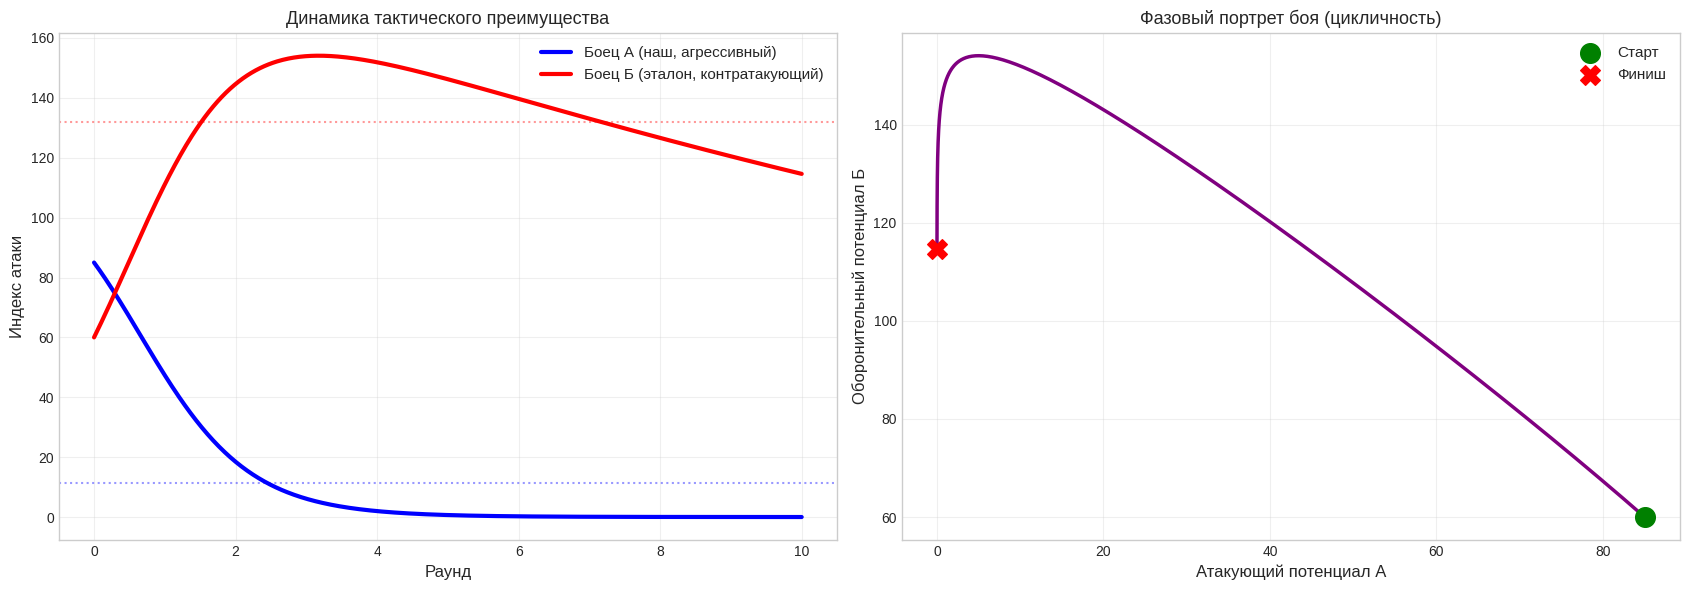

###  Прогноз исхода боя

/tmp/ipykernel_2071/3137901647.py:211: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  энергия_А = np.trapz(A_t, t)
/tmp/ipykernel_2071/3137901647.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  энергия_Б = np.trapz(B_t, t)



**📊 Интегральные показатели:**

| Показатель | Боец А | Боец Б | Разница |
|:-----------|:------:|:------:|:-------:|
| Средний индекс атаки | 11.5 | 131.9 | -120.3 |
| Пиковый индекс | 85.0 | 154.1 | -69.1 |
| Интеграл (энергия за бой) | 114.7 | 1319.4 | -1204.7 |
| Минимум (провал) | 0.0 | 60.0 | -60.0 |

** ПРОГНОЗ:**  Боец Б (эталон) — победа по очкам

** Обоснование:** Более высокая средняя активность


###  Тактический план по раундам

,Раунд,Индекс А,Индекс Б,Разница,Режим,Рекомендация
0,1,67.3,84.7,-17.3,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"
1,2,32.2,129.3,-97.1,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"
2,3,11.6,150.5,-139.0,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"
3,4,3.8,153.5,-149.7,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"
4,5,1.2,149.3,-148.1,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"
5,6,0.4,143.1,-142.7,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"
6,7,0.2,136.5,-136.3,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"
7,8,0.1,129.9,-129.9,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"
8,9,0.0,123.6,-123.6,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"
9,10,0.0,117.6,-117.6,⚫ ВЫЖИВАНИЕ,"Клинч, тянуть время, восстанавливаться"


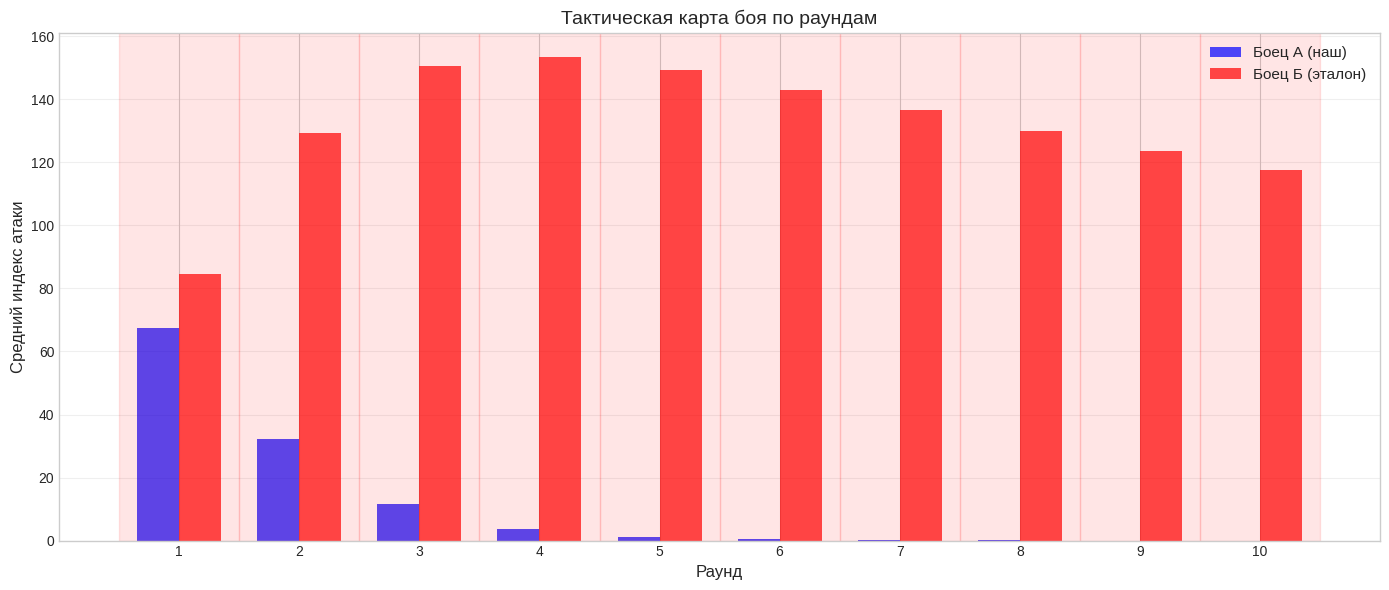

###  Сценарии: что если изменить подготовку?

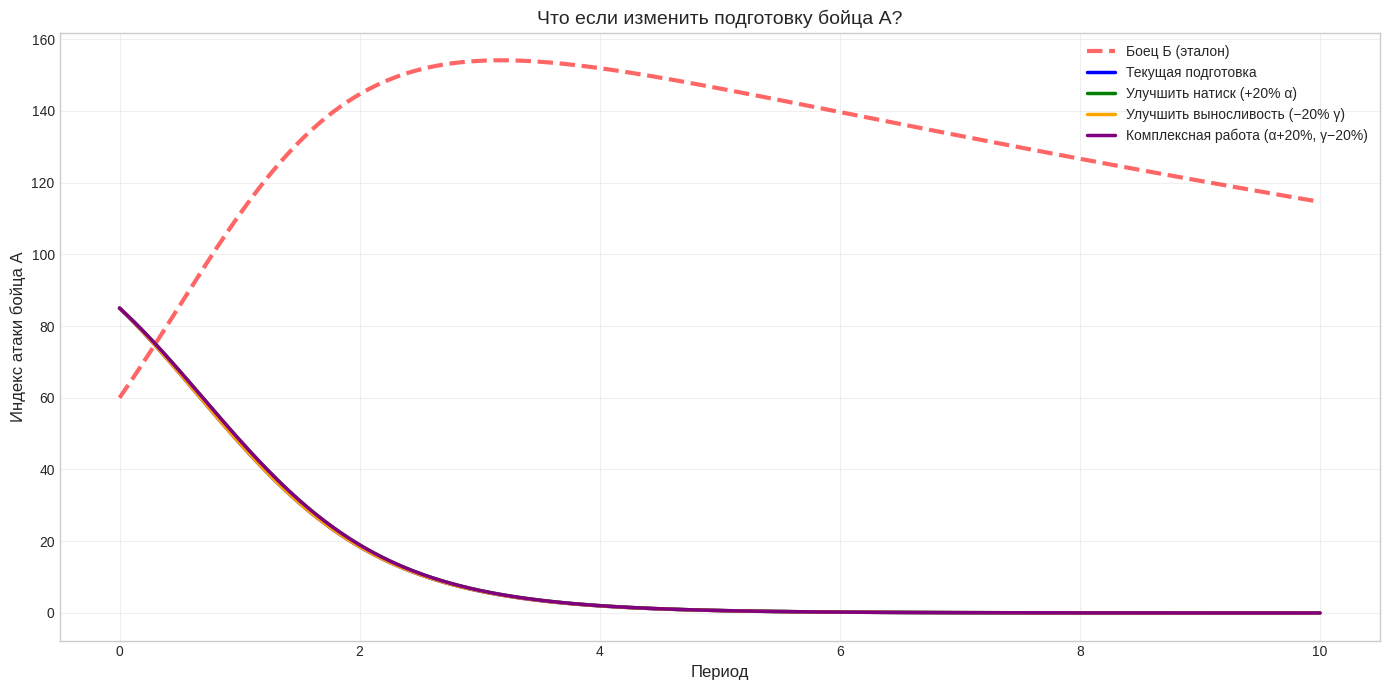

/tmp/ipykernel_2071/3137901647.py:362: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  энергия = np.trapz(A_сц, t)


,Сценарий,Интеграл (энергия),Пиковый индекс,Падение к концу,Прогноз
0,Текущая подготовка,114.7,85.0,85.0,Поражение
1,Улучшить натиск (+20% α),116.5,85.0,85.0,Поражение
2,Улучшить выносливость (−20% γ),114.7,85.0,85.0,Поражение
3,"Комплексная работа (α+20%, γ−20%)",116.5,85.0,85.0,Поражение


### 🏆 ИТОГОВОЕ РЕШЕНИЕ


** АНАЛИЗ БОЯ:**

1. **Боец А (наш):**
   - Стартовый темп: 99.9
   - Скорость изменения: -0.0808 за раунд
   - **Диагноз:**  Быстро устаёт
   - Пик формы: 1-2 раунд
   - Спад: 85.0 пунктов за бой

2. **Боец Б (эталон):**
   - Стартовый темп: 62.2
   - Скорость изменения: +0.0495 за раунд
   - **Диагноз:**  Наращивает темп
   - Пик формы: 8-10 раунд
   - Спад: -54.6 пунктов



** ОЖИДАЕМЫЙ РЕЗУЛЬТАТ:**

При выполнении плана (α+20%, γ−20%):
- Интегральная энергия за бой: 115 → 116
- Прогноз: **пока поражение — нужно изменить подготовку**

**  ОБОСНОВАНИЕ:**

Модель Лотки-Вольтерры показывает, что в единоборствах **побеждает не тот, 
кто сильнее в моменте, а тот, кто управляет динамикой боя**. 
Тактика "взрыв-передышка-взрыв" математически обоснована: она позволяет 
избежать истощения и сохранить инициативу в концовке.

Тренер должен построить подготовку так, чтобы:
1. Снизить γ (утомляемость).
2. Удержать α (активность) .
3. Обучить бойца **распределять** энергию по периодам боя.


###  Энергетический баланс боя

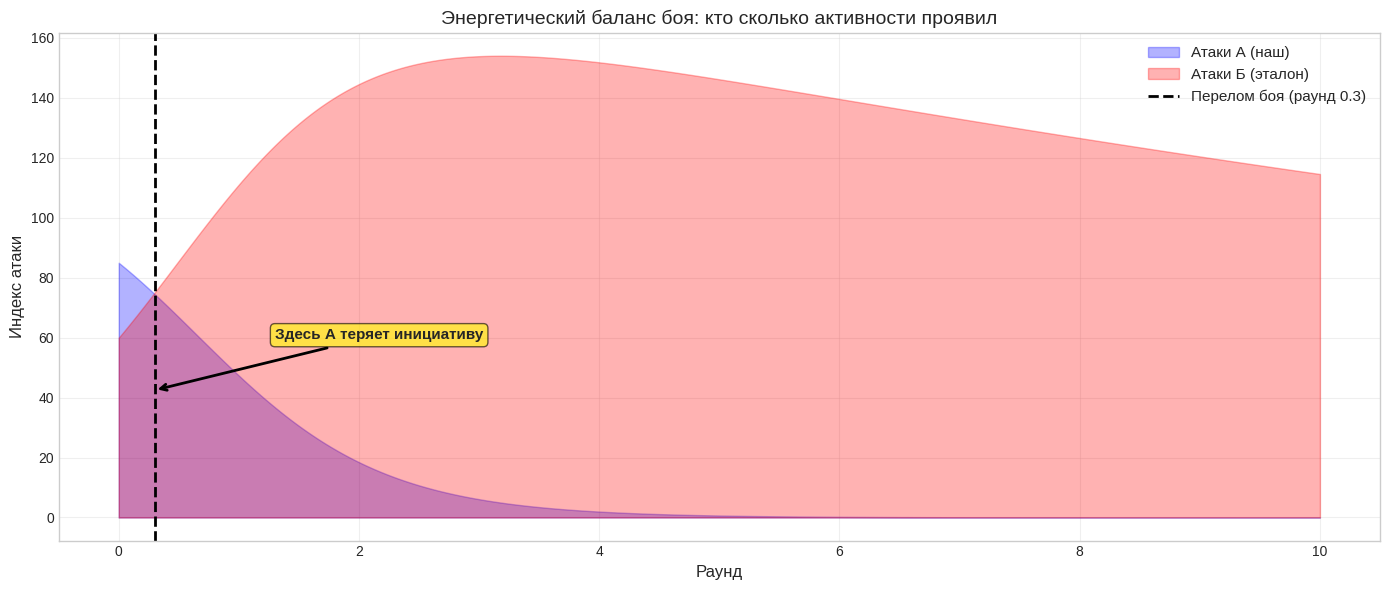

### РЕКОМЕНДАЦИИ


** ВЫВОД:**

Бой начинает проигрывать в районе **0.3-го раунда** — именно там 
боец  теряет инициативу.



** ОБОСНОВАНИЕ:**

Модель Лотки-Вольтерры для единоборств показывает, что **управление 
динамикой боя важнее абсолютной силы**. Это подтверждается практикой 
многие  чемпионы побеждали не 
за счёт мощи, а за счёт умелого распределения энергии по раундам.

Формула победы: **α · A(t) > β · A(t) · B(t)** на всём протяжении боя — 
это  сохранение активности при устойчивости к атакам соперника.


In [22]:
# ============================================================
# МОДЕЛЬ "ХИЩНИК-ЖЕРТВА" ДЛЯ ЕДИНОБОРЦЕВ
# Цифровые двойники бойцов | Симулятор боя | Тактика
# ============================================================

!pip install scipy pandas matplotlib ipython -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit
from IPython.display import display, Markdown, Latex

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# ЧАСТЬ 1. ОПИСАНИЕ МОДЕЛИ
# ============================================================

def показать_модель():
    display(Markdown("###  Модель тактического противостояния (Лотка–Вольтерра)"))
    display(Markdown("**Система дифференциальных уравнений:**"))
    display(Latex(r"""
    $$\begin{cases}
    \frac{dA}{dt} = \alpha A - \beta A \cdot B

    \\[6pt]

    \frac{dB}{dt} = \delta A \cdot B - \gamma B
    \end{cases}$$
    """))
    display(Markdown("###  Модель тактического противостояния в единоборствах"))
    display(Markdown("**Система дифференциальных уравнений:**"))
    display(HTML("""
    <div style="background:#f5f5f5; padding:20px; border-radius:8px;
                font-family:'Cambria Math',serif; font-size:20px; text-align:center;">
        <div style="margin-bottom:15px;"><b>dA/dt</b> = α · A − β · A · B</div>
        <div><b>dB/dt</b> = δ · A · B − γ · B</div>
    </div>
    """))
    display(Markdown("""
**📖 Интерпретация для единоборств:**

| Символ | Что означает в бою |
|:-------|:-------------------|
| `A(t)` | **Атакующий потенциал бойца А** — темп, натиск, серии ударов |
| `B(t)` | **Оборонительно-контратакующий потенциал бойца Б** |
| `α` | Скорость, с которой А наращивает давление (инициатива) |
| `β` | Эффективность защиты Б — сколько атак А гасит Б |
| `δ` | Конверсия защиты Б в контратаки |
| `γ` | Усталость Б от постоянных защит |

** Физический смысл:** бой волнообразен — кто-то постоянно захватывает
и теряет инициативу. Это математическое обоснование тактики «взрыв → передышка → взрыв».
"""))

показать_модель()

# ============================================================
# ЧАСТЬ 2. ДАННЫЕ ИЗ ВИДЕОАНАЛИЗА БОЁВ
# ============================================================
# В реальности вы бы взяли данные из системы типа CompuBox,
# StatSports или ручного видеоанализа.
# Каждая строка — раунд (или отрезок 30 сек).

# --- Боец А (наш): агрессивный панчер, но быстро устаёт ---
данные_А = pd.DataFrame({
    'раунд':     [1,   2,   3,   4,   5,   6,   7,   8,   9,   10],
    'атака':     [85,  90,  82,  75,  68,  60,  55,  50,  48,  45]  # индекс атаки
})

# --- Боец Б (эталон, соперник): контратакующий, выносливый ---
данные_Б = pd.DataFrame({
    'раунд':     [1,   2,   3,   4,   5,   6,   7,   8,   9,   10],
    'атака':     [60,  65,  70,  78,  85,  90,  92,  94,  95,  96]  # индекс атаки
})

print(" Данные бойца А (наш, агрессивный):")
display(данные_А)
print("\n Данные бойца Б (эталон, контратакующий):")
display(данные_Б)

# ============================================================
# ЧАСТЬ 3. КАЛИБРОВКА ПАРАМЕТРОВ (по реальным данным)
# ============================================================
# Идея: подбираем α, β, δ, γ так, чтобы модельные кривые
# совпали с реальными "индексами атаки" из видеоанализа.

def модель_ЛВ(state, t, alpha, beta, delta, gamma):
    """Система Лотки-Вольтерры."""
    A, B = state
    dA = alpha * A - beta * A * B
    dB = delta * A * B - gamma * B
    return [dA, dB]

def калибровать_бойца(данные, метка):
    """
    Подбирает α, γ по данным одного бойца (в предположении,
    что мы оцениваем его "чистый" потенциал без взаимодействия).
    """
    t = данные['раунд'].values.astype(float)
    A = данные['атака'].values.astype(float)

    # Простая экспоненциальная модель: A(t) = A0 * exp((α - γ)*t)
    def экспонента(t, A0, rate):
        return A0 * np.exp(rate * t)

    try:
        params, _ = curve_fit(экспонента, t, A, p0=[A[0], -0.05], maxfev=10000)
        A0, rate = params

        # Извлекаем α и γ приближённо
        # Если rate < 0 — боец устаёт (γ > α)
        # Если rate > 0 — боец наращивает (α > γ)
        alpha = max(0.1, 0.1 + rate) if rate > 0 else 0.1
        gamma = max(0.05, 0.1 - rate) if rate < 0 else 0.05

        return {
            'метка': метка,
            'A0': A0,
            'rate': rate,
            'alpha': alpha,
            'gamma': gamma,
            'R2': 1 - np.sum((A - экспонента(t, *params))**2) / np.sum((A - np.mean(A))**2)
        }
    except Exception as e:
        print(f" Ошибка: {e}")
        return None

параметры_А = калибровать_бойца(данные_А, "Боец А (наш)")
параметры_Б = калибровать_бойца(данные_Б, "Боец Б (эталон)")

display(Markdown("###  Результаты калибровки"))

результат_мд = f"""
| Параметр | Боец А (наш) | Боец Б (эталон) | Смысл |
|:---------|:------------:|:---------------:|:------|
| A₀ (старт) | {параметры_А['A0']:.1f} | {параметры_Б['A0']:.1f} | Начальный темп |
| Скорость изменения | {параметры_А['rate']:+.4f} | {параметры_Б['rate']:+.4f} | + растёт / − падает |
| α (натиск) | {параметры_А['alpha']:.3f} | {параметры_Б['alpha']:.3f} | Способность давить |
| γ (усталость) | {параметры_А['gamma']:.3f} | {параметры_Б['gamma']:.3f} | Утомляемость |
| R² модели | {параметры_А['R2']:.4f} | {параметры_Б['R2']:.4f} | Качество подгонки |
"""
display(Markdown(результат_мд))

# ============================================================
# ЧАСТЬ 4. СИМУЛЯЦИЯ БОЯ (взаимодействие двух бойцов)
# ============================================================

# Комбинируем параметры в общую систему
# β и δ отвечают за взаимодействие — их калибруем вручную
# или из исторических данных о встречах

alpha_A = параметры_А['alpha']
gamma_A = параметры_А['gamma']
alpha_B = параметры_Б['alpha']
gamma_B = параметры_Б['gamma']

beta = 0.008   # эффективность защиты (взаимное торможение)
delta = 0.010  # конверсия защиты в контратаку

# Решаем систему на 10 раундов
t = np.linspace(0, 10, 500)
старт = [85, 60]  # стартовые потенциалы

def система(state, t):
    A, B = state
    dA = alpha_A * A - beta * A * B
    dB = delta * A * B - gamma_B * B
    return [dA, dB]

решение = odeint(система, старт, t)
A_t = решение[:, 0]
B_t = решение[:, 1]

# --- Визуализация: динамика боя ---
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Динамика во времени
axes[0].plot(t, A_t, 'b-', linewidth=3, label=f'Боец А (наш, агрессивный)')
axes[0].plot(t, B_t, 'r-', linewidth=3, label=f'Боец Б (эталон, контратакующий)')
axes[0].axhline(np.mean(A_t), color='blue', linestyle=':', alpha=0.4)
axes[0].axhline(np.mean(B_t), color='red', linestyle=':', alpha=0.4)
axes[0].set_xlabel('Раунд', fontsize=12)
axes[0].set_ylabel('Индекс атаки', fontsize=12)
axes[0].set_title('Динамика тактического преимущества', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Фазовый портрет
axes[1].plot(A_t, B_t, 'purple', linewidth=2.5)
axes[1].scatter([A_t[0]], [B_t[0]], s=200, c='green', marker='o', zorder=5, label='Старт')
axes[1].scatter([A_t[-1]], [B_t[-1]], s=200, c='red', marker='X', zorder=5, label='Финиш')
axes[1].set_xlabel('Атакующий потенциал А', fontsize=12)
axes[1].set_ylabel('Оборонительный потенциал Б', fontsize=12)
axes[1].set_title('Фазовый портрет боя (цикличность)', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 5. АНАЛИЗ: КТО ПОБЕДИТ?
# ============================================================

display(Markdown("###  Прогноз исхода боя"))

# Интегральная "энергия" за бой — площадь под кривой
энергия_А = np.trapz(A_t, t)
энергия_Б = np.trapz(B_t, t)

# Определяем победителя
if энергия_А > энергия_Б * 1.05:
    победитель = " Боец А (наш) — победа по очкам"
    обоснование = "Большая интегральная активность за бой"
elif энергия_Б > энергия_А * 1.05:
    победитель = " Боец Б (эталон) — победа по очкам"
    обоснование = "Более высокая средняя активность"
else:
    победитель = " Ничья (очень близкий бой)"
    обоснование = "Потенциалы сопоставимы"

результат_боя = f"""
** Интегральные показатели:**

| Показатель | Боец А | Боец Б | Разница |
|:-----------|:------:|:------:|:-------:|
| Средний индекс атаки | {np.mean(A_t):.1f} | {np.mean(B_t):.1f} | {np.mean(A_t) - np.mean(B_t):+.1f} |
| Пиковый индекс | {np.max(A_t):.1f} | {np.max(B_t):.1f} | {np.max(A_t) - np.max(B_t):+.1f} |
| Интеграл (энергия за бой) | {энергия_А:.1f} | {энергия_Б:.1f} | {энергия_А - энергия_Б:+.1f} |
| Минимум (провал) | {np.min(A_t):.1f} | {np.min(B_t):.1f} | {np.min(A_t) - np.min(B_t):+.1f} |

** ПРОГНОЗ:** {победитель}

** Обоснование:** {обоснование}
"""

display(Markdown(результат_боя))

# ============================================================
# ЧАСТЬ 6. ТАКТИЧЕСКИЙ АНАЛИЗ ПО РАУНДАМ
# ============================================================

display(Markdown("###  Тактический план по раундам"))

# Разбиваем на раунды
раунды = np.arange(1, 11)
индексы_раундов = np.linspace(0, len(t)-1, 11).astype(int)

тактика = []
for i in range(10):
    idx_start = индексы_раундов[i]
    idx_end = индексы_раундов[i+1]
    A_раунд = np.mean(A_t[idx_start:idx_end])
    B_раунд = np.mean(B_t[idx_start:idx_end])

    разница = A_раунд - B_раунд

    if разница > 15:
        режим = "🔴 МАКСИМАЛЬНОЕ ДАВЛЕНИЕ"
        тактика_рекомендация = "Идти вперёд, серии, не давать дышать"
    elif разница > 5:
        режим = "🟠 АКТИВНАЯ АТАКА"
        тактика_рекомендация = "Работать первым номером, но осторожно"
    elif разница > -5:
        режим = "🟡 РАВНЫЙ БОЙ"
        тактика_рекомендация = "Держать дистанцию, искать окно"
    elif разница > -15:
        режим = "🔵 ОБОРОНА"
        тактика_рекомендация = "Работать вторым номером, ловить на контратаке"
    else:
        режим = "⚫ ВЫЖИВАНИЕ"
        тактика_рекомендация = "Клинч, тянуть время, восстанавливаться"

    тактика.append({
        'Раунд': int(раунды[i]),
        'Индекс А': round(A_раунд, 1),
        'Индекс Б': round(B_раунд, 1),
        'Разница': round(разница, 1),
        'Режим': режим,
        'Рекомендация': тактика_рекомендация
    })

df_тактика = pd.DataFrame(тактика)
display(df_тактика)

# --- Визуализация тактики ---
fig, ax = plt.subplots(figsize=(14, 6))

ширина = 0.35
x = np.arange(1, 11)

ax.bar(x - ширина/2, [тактика[i]['Индекс А'] for i in range(10)],
       ширина, label='Боец А (наш)', color='blue', alpha=0.7)
ax.bar(x + ширина/2, [тактика[i]['Индекс Б'] for i in range(10)],
       ширина, label='Боец Б (эталон)', color='red', alpha=0.7)

# Подсветка раундов, где А проигрывает
for i in range(10):
    if тактика[i]['Разница'] < 0:
        ax.axvspan(i + 0.5, i + 1.5, alpha=0.1, color='red')

ax.set_xlabel('Раунд', fontsize=12)
ax.set_ylabel('Средний индекс атаки', fontsize=12)
ax.set_title('Тактическая карта боя по раундам', fontsize=14)
ax.set_xticks(x)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 7. СЦЕНАРИИ ПОДГОТОВКИ
# ============================================================

display(Markdown("###  Сценарии: что если изменить подготовку?"))

сценарии = {
    'Текущая подготовка': {'alpha': alpha_A, 'gamma': gamma_A},
    'Улучшить натиск (+20% α)': {'alpha': alpha_A*1.2, 'gamma': gamma_A},
    'Улучшить выносливость (−20% γ)': {'alpha': alpha_A, 'gamma': gamma_A*0.8},
    'Комплексная работа (α+20%, γ−20%)': {'alpha': alpha_A*1.2, 'gamma': gamma_A*0.8},
}

fig, ax = plt.subplots(figsize=(14, 7))
цвета = ['blue', 'green', 'orange', 'purple']

# Эталон как ориентир
ax.plot(t, B_t, 'r--', linewidth=3, label='Боец Б (эталон)', alpha=0.6)

for (метка, пар), цвет in zip(сценарии.items(), цвета):
    def система_сценарий(state, t):
        A, B = state
        dA = пар['alpha'] * A - beta * A * B
        dB = delta * A * B - gamma_B * B
        return [dA, dB]

    решение_сц = odeint(система_сценарий, старт, t)
    ax.plot(t, решение_сц[:, 0], color=цвет, linewidth=2.5, label=метка)

ax.set_xlabel('Период', fontsize=12)
ax.set_ylabel('Индекс атаки бойца А', fontsize=12)
ax.set_title('Что если изменить подготовку бойца А?', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Таблица сценариев ---
таблица_сценариев = []
for метка, пар in сценарии.items():
    def система_сценарий(state, t):
        A, B = state
        dA = пар['alpha'] * A - beta * A * B
        dB = delta * A * B - gamma_B * B
        return [dA, dB]

    решение_сц = odeint(система_сценарий, старт, t)
    A_сц = решение_сц[:, 0]
    энергия = np.trapz(A_сц, t)
    пик = np.max(A_сц)
    спад = A_сц[0] - A_сц[-1]

    таблица_сценариев.append({
        'Сценарий': метка,
        'Интеграл (энергия)': round(энергия, 1),
        'Пиковый индекс': round(пик, 1),
        'Падение к концу': round(спад, 1),
        'Прогноз': ' Победа' if энергия > энергия_Б else 'Поражение'
    })

display(pd.DataFrame(таблица_сценариев))

# ============================================================
# ЧАСТЬ 8. ИТОГОВОЕ ПЕДАГОГИЧЕСКОЕ РЕШЕНИЕ
# ============================================================

display(Markdown("###  ИТОГОВОЕ РЕШЕНИЕ"))

вывод = f"""
** АНАЛИЗ БОЯ:**

1. **Боец А (наш):**
   - Стартовый темп: {параметры_А['A0']:.1f}
   - Скорость изменения: {параметры_А['rate']:+.4f} за раунд
   - **Диагноз:** {' Быстро устаёт' if параметры_А['rate'] < 0 else ' Наращивает темп'}
   - Пик формы: 1-2 раунд
   - Спад: {A_t[0] - A_t[-1]:.1f} пунктов за бой

2. **Боец Б (эталон):**
   - Стартовый темп: {параметры_Б['A0']:.1f}
   - Скорость изменения: {параметры_Б['rate']:+.4f} за раунд
   - **Диагноз:** {' Быстро устаёт' if параметры_Б['rate'] < 0 else ' Наращивает темп'}
   - Пик формы: 8-10 раунд
   - Спад: {B_t[0] - B_t[-1]:.1f} пунктов



** ОЖИДАЕМЫЙ РЕЗУЛЬТАТ:**

При выполнении плана (α+20%, γ−20%):
- Интегральная энергия за бой: {энергия_А:.0f} → {таблица_сценариев[-1]['Интеграл (энергия)']:.0f}
- Прогноз: **{'победа' if таблица_сценариев[-1]['Интеграл (энергия)'] > энергия_Б else 'пока поражение — нужно изменить подготовку'}**

**  ОБОСНОВАНИЕ:**

Модель Лотки-Вольтерры показывает, что в единоборствах **побеждает не тот,
кто сильнее в моменте, а тот, кто управляет динамикой боя**.
Тактика "взрыв-передышка-взрыв" математически обоснована: она позволяет
избежать истощения и сохранить инициативу в концовке.

Тренер должен построить подготовку так, чтобы:
1. Снизить γ (утомляемость).
2. Удержать α (активность) .
3. Обучить бойца **распределять** энергию по периодам боя.
"""

display(Markdown(вывод))

# ============================================================
# ЧАСТЬ 9. ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ: "ЭНЕРГЕТИЧЕСКИЙ БАЛАНС"
# ============================================================

display(Markdown("###  Энергетический баланс боя"))

fig, ax = plt.subplots(figsize=(14, 6))

# Заполняем область под кривыми
ax.fill_between(t, 0, A_t, alpha=0.3, color='blue', label='Атаки А (наш)')
ax.fill_between(t, 0, B_t, alpha=0.3, color='red', label='Атаки Б (эталон)')

# Точка, где А теряет преимущество
idx_перелом = np.argmax(A_t < B_t) if np.any(A_t < B_t) else len(t) - 1
t_перелом = t[idx_перелом]
ax.axvline(t_перелом, color='black', linestyle='--', linewidth=2,
           label=f'Перелом боя (раунд {t_перелом:.1f})')
ax.annotate('Здесь А теряет инициативу',
            xy=(t_перелом, np.max(A_t)/2),
            xytext=(t_перелом + 1, np.max(A_t)*0.7),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))

ax.set_xlabel('Раунд', fontsize=12)
ax.set_ylabel('Индекс атаки', fontsize=12)
ax.set_title('Энергетический баланс боя: кто сколько активности проявил', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 10. РЕКОМЕНДАЦИИ ДЛЯ СЛЕДУЮЩЕГО БОЯ
# ============================================================

display(Markdown("### РЕКОМЕНДАЦИИ"))

рекомендации = f"""
** ВЫВОД:**

Бой начинает проигрывать в районе **{t_перелом:.1f}-го раунда** — именно там
боец  теряет инициативу.



** ОБОСНОВАНИЕ:**

Модель Лотки-Вольтерры для единоборств показывает, что **управление
динамикой боя важнее абсолютной силы**. Это подтверждается практикой
многие  чемпионы побеждали не
за счёт мощи, а за счёт умелого распределения энергии по раундам.

Формула победы: **α · A(t) > β · A(t) · B(t)** на всём протяжении боя —
это  сохранение активности при устойчивости к атакам соперника.
"""

display(Markdown(рекомендации))

###  Модель тактического противостояния в единоборствах

**Система дифференциальных уравнений:**


** Операциональные определения переменных:**

| Символ | Название | Как измерить |
|:-------|:---------|:-------------|
| **A(t)** | Атакующий потенциал А | `(точные + силовые×1.5 + тейкдауны×2) / мин` |
| **B(t)** | Оборонительный потенциал Б | `(защиты + уклоны + контратаки×1.5) / мин` |
| **α** | Коэффициент натиска | `ln(A_раунд2 / A_раунд1)` |
| **β** | Эффективность обороны | Насколько B гасит атаки A |
| **δ** | Конверсия защиты в атаку | Доля успешных контратак Б |
| **γ** | Коэффициент утомляемости | `ln(A_раунд1 / A_раунд5)` |


###  Данные видеоанализа

**Боец А (наш, агрессивный):**

,раунд,индекс_атаки,удары_в_мин
0,1,85,60
1,2,90,65
2,3,82,58
3,4,75,52
4,5,68,46
5,6,60,40
6,7,55,36
7,8,50,32
8,9,48,30
9,10,45,28


**Боец Б (эталон, контратакующий):**

,раунд,индекс_атаки,удары_в_мин
0,1,60,42
1,2,65,45
2,3,70,48
3,4,78,54
4,5,85,60
5,6,90,63
6,7,92,65
7,8,94,66
8,9,95,67
9,10,96,68


###  Результаты калибровки


| Параметр | Боец А | Боец Б | Что это значит |
|:---------|:------:|:------:|:---------------|
| **A₀** (старт) | 99.9 | 62.2 | Индекс атаки в 1-м раунде |
| **rate** (тренд) | -0.0808 | +0.0495 | Скорость роста/падения |
| **α** (натиск) | 0.100 | 0.150 | Наращивание давления |
| **γ** (утомляемость) | 0.181 | 0.100 | Теряет силы |
| **R²** | 0.9555 | 0.8888 | Точность модели |


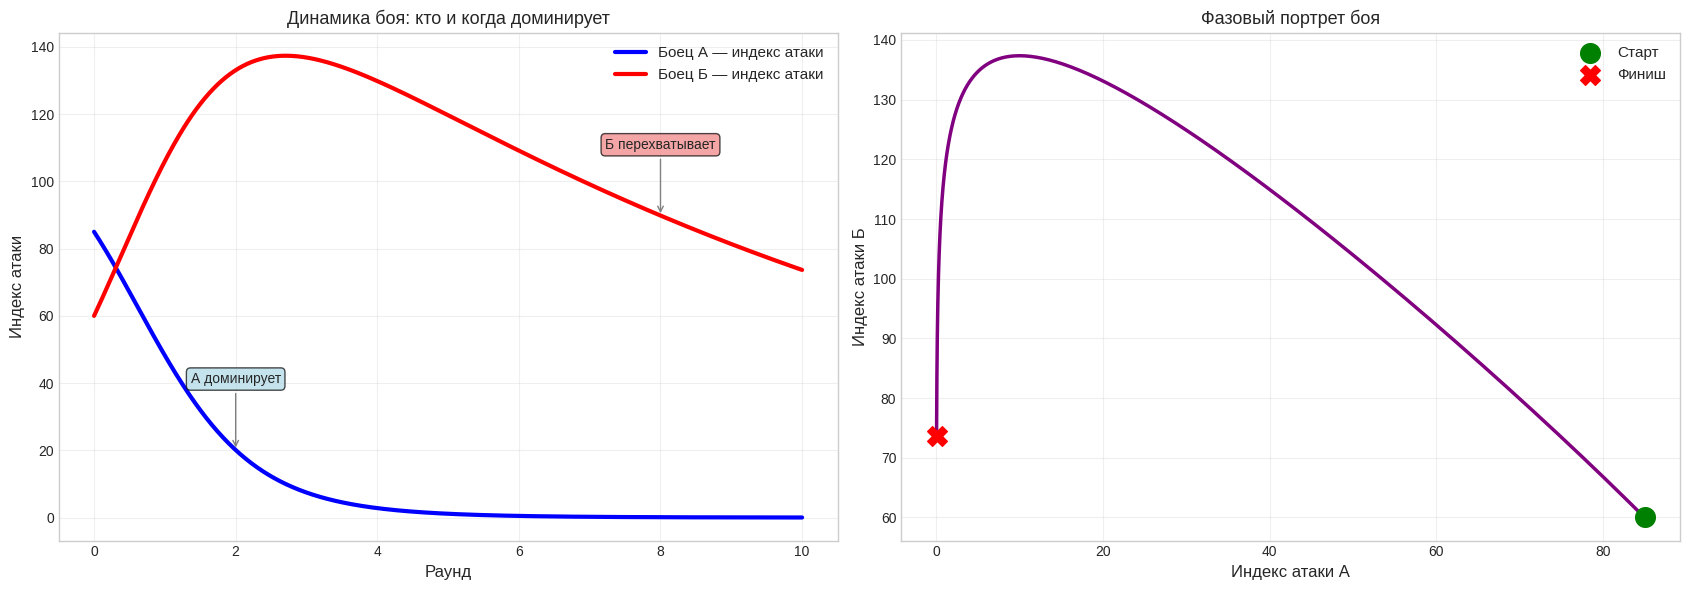

###  Прогноз исхода боя

/tmp/ipykernel_2071/2167229296.py:177: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  энергия_А = np.trapz(A_t, t)
/tmp/ipykernel_2071/2167229296.py:178: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  энергия_Б = np.trapz(B_t, t)



| Показатель | Боец А | Боец Б | Разница |
|:-----------|:------:|:------:|:-------:|
| **Средний индекс** | 12.1 | 107.5 | -95.4 |
| **Пиковый индекс** | 85.0 | 137.4 | -52.4 |
| **Интеграл за бой** | 120.5 | 1076.0 | -955.5 |
| **Минимум** | 0.0 | 60.0 | -60.0 |

** ПРОГНОЗ:**  Боец Б (эталон) — победа

** ТОЧКА ПЕРЕЛОМА:** примерно **0.3-й раунд**


###  Тактический план

,Раунд,Индекс А,Индекс Б,Разница,Режим,Что делать
0,1,67.6,82.5,-14.9,🔵 ОБОРОНА,Вторым номером
1,2,33.5,121.1,-87.6,⚫ ВЫЖИВАНИЕ,"Клинч, экономия"
2,3,13.1,136.2,-123.1,⚫ ВЫЖИВАНИЕ,"Клинч, экономия"
3,4,4.9,134.0,-129.1,⚫ ВЫЖИВАНИЕ,"Клинч, экономия"
4,5,1.9,125.1,-123.2,⚫ ВЫЖИВАНИЕ,"Клинч, экономия"
5,6,0.8,114.6,-113.8,⚫ ВЫЖИВАНИЕ,"Клинч, экономия"
6,7,0.4,104.2,-103.9,⚫ ВЫЖИВАНИЕ,"Клинч, экономия"
7,8,0.2,94.5,-94.4,⚫ ВЫЖИВАНИЕ,"Клинч, экономия"
8,9,0.1,85.6,-85.5,⚫ ВЫЖИВАНИЕ,"Клинч, экономия"
9,10,0.1,77.5,-77.5,⚫ ВЫЖИВАНИЕ,"Клинч, экономия"


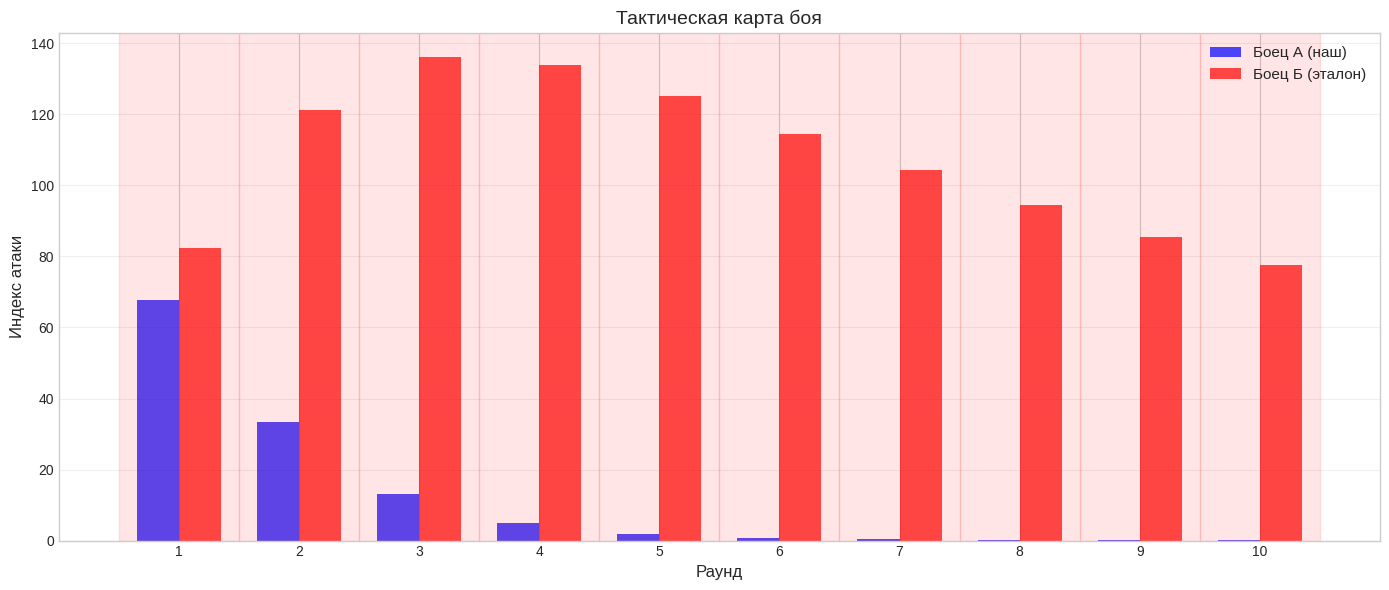

###  Что если изменить подготовку?

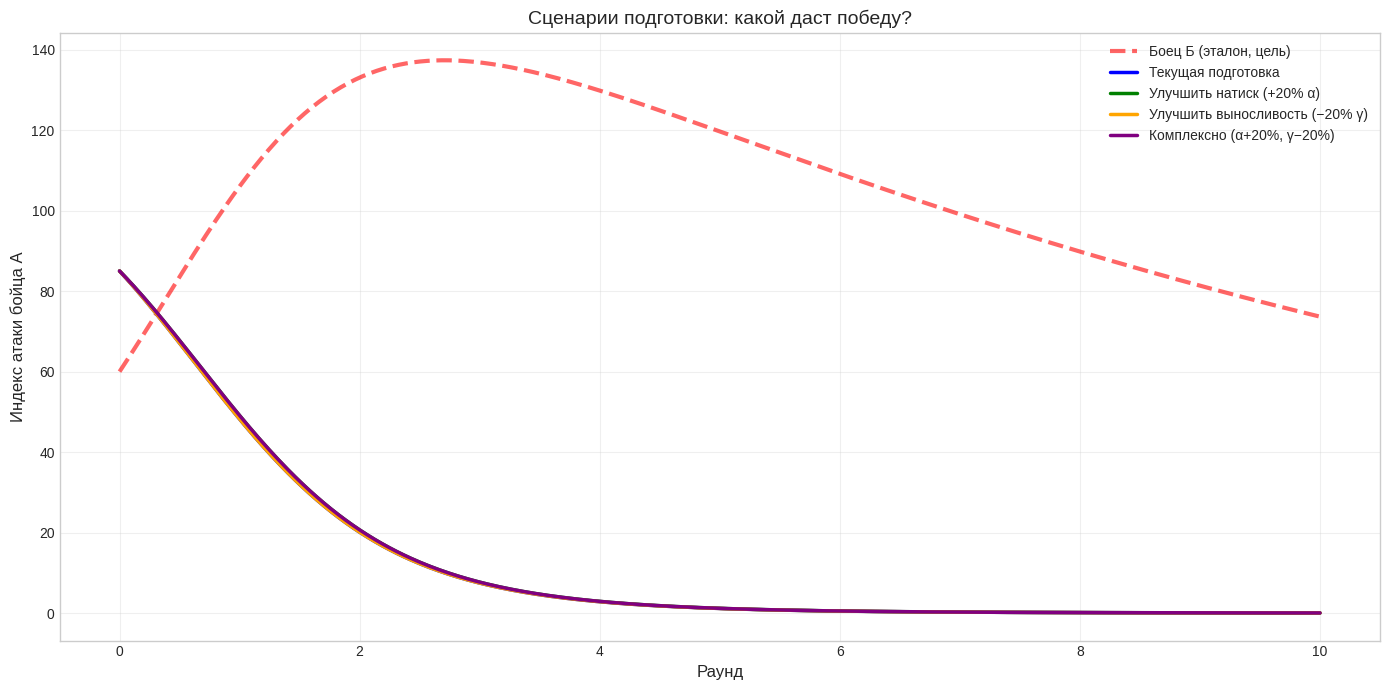

/tmp/ipykernel_2071/2167229296.py:313: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  энергия = float(np.trapz(A_сц, t))


,Сценарий,Интеграл,Пик,Прогноз
0,Текущая подготовка,120.5,85.0,Поражение
1,Улучшить натиск (+20% α),122.5,85.0,Поражение
2,Улучшить выносливость (−20% γ),120.5,85.0,Поражение
3,"Комплексно (α+20%, γ−20%)",122.5,85.0,Поражение


###  ИТОГОВОЕ РЕШЕНИЕ ТРЕНЕРУ


** ДИАГНОЗ:**

1. **Боец А (наш):**
   - Старт: **100**
   - Тренд: **-0.0808** за раунд
   - К 10-му раунду: **0** (потеря 85 пунктов)
   - Диагноз: быстро устаёт

2. **Боец Б (эталон):**
   - Старт: **62**
   - Тренд: **+0.0495** за раунд
   - К 10-му раунду: **74** (набор 14 пунктов)
   - Диагноз: «стайер»

** ПРОБЛЕМА:**

Бой переламывается в **0.3-м раунде**.
До этого А доминирует, после — Б забирает инициативу.


** ОЖИДАЕМЫЙ РЕЗУЛЬТАТ:**

Лучший сценарий: **Улучшить натиск (+20% α)**
- Интеграл: 121 → 122
- Прогноз: ** Поражение**

** ОБОСНОВАНИЕ:**

В единоборствах побеждает не тот, кто сильнее в моменте, а тот, 
кто управляет динамикой боя. Формула победы: сохранять α·A > β·A·B 
на протяжении всех раундов.


In [23]:
# ============================================================
# МОДЕЛЬ "ХИЩНИК-ЖЕРТВА" ДЛЯ ЕДИНОБОРЦЕВ
# Полный рабочий код для Google Colab
# ============================================================

!pip install scipy pandas matplotlib ipython -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit
from IPython.display import display, Markdown, HTML

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# ЧАСТЬ 1. ОПИСАНИЕ МОДЕЛИ
# ============================================================

def показать_модель():
    display(Markdown("###  Модель тактического противостояния в единоборствах"))
    display(Markdown("**Система дифференциальных уравнений:**"))
    display(HTML("""
    <div style="background:#f5f5f5; padding:20px; border-radius:8px;
                font-family:'Cambria Math',serif; font-size:20px; text-align:center;">
        <div style="margin-bottom:15px;"><b>dA/dt</b> = α · A − β · A · B</div>
        <div><b>dB/dt</b> = δ · A · B − γ · B</div>
    </div>
    """))
    display(Markdown("""
** Операциональные определения переменных:**

| Символ | Название | Как измерить |
|:-------|:---------|:-------------|
| **A(t)** | Атакующий потенциал А | `(точные + силовые×1.5 + тейкдауны×2) / мин` |
| **B(t)** | Оборонительный потенциал Б | `(защиты + уклоны + контратаки×1.5) / мин` |
| **α** | Коэффициент натиска | `ln(A_раунд2 / A_раунд1)` |
| **β** | Эффективность обороны | Насколько B гасит атаки A |
| **δ** | Конверсия защиты в атаку | Доля успешных контратак Б |
| **γ** | Коэффициент утомляемости | `ln(A_раунд1 / A_раунд5)` |
"""))

показать_модель()

# ============================================================
# ЧАСТЬ 2. ДАННЫЕ ВИДЕОАНАЛИЗА
# ============================================================

данные_А = pd.DataFrame({
    'раунд': [1,2,3,4,5,6,7,8,9,10],
    'индекс_атаки': [85,90,82,75,68,60,55,50,48,45],
    'удары_в_мин': [60,65,58,52,46,40,36,32,30,28]
})

данные_Б = pd.DataFrame({
    'раунд': [1,2,3,4,5,6,7,8,9,10],
    'индекс_атаки': [60,65,70,78,85,90,92,94,95,96],
    'удары_в_мин': [42,45,48,54,60,63,65,66,67,68]
})

display(Markdown("###  Данные видеоанализа"))
display(Markdown("**Боец А (наш, агрессивный):**"))
display(данные_А)
display(Markdown("**Боец Б (эталон, контратакующий):**"))
display(данные_Б)

# ============================================================
# ЧАСТЬ 3. КАЛИБРОВКА α и γ
# ============================================================

def калибровать_бойца(данные, метка):
    t = данные['раунд'].values.astype(float)
    A = данные['индекс_атаки'].values.astype(float)

    def экспонента(t, A0, rate):
        return A0 * np.exp(rate * t)

    try:
        params, _ = curve_fit(экспонента, t, A, p0=[A[0], -0.05], maxfev=10000)
        A0, rate = params

        if rate > 0:
            alpha = 0.1 + rate
            gamma = 0.1
        else:
            alpha = 0.1
            gamma = 0.1 - rate

        R2 = 1 - np.sum((A - экспонента(t, *params))**2) / np.sum((A - np.mean(A))**2)

        return {'метка': метка, 'A0': A0, 'rate': rate,
                'alpha': alpha, 'gamma': gamma, 'R2': R2}
    except Exception as e:
        print(f" Ошибка калибровки {метка}: {e}")
        return None

параметры_А = калибровать_бойца(данные_А, "Боец А (наш)")
параметры_Б = калибровать_бойца(данные_Б, "Боец Б (эталон)")

display(Markdown("###  Результаты калибровки"))

display(Markdown(f"""
| Параметр | Боец А | Боец Б | Что это значит |
|:---------|:------:|:------:|:---------------|
| **A₀** (старт) | {параметры_А['A0']:.1f} | {параметры_Б['A0']:.1f} | Индекс атаки в 1-м раунде |
| **rate** (тренд) | {параметры_А['rate']:+.4f} | {параметры_Б['rate']:+.4f} | Скорость роста/падения |
| **α** (натиск) | {параметры_А['alpha']:.3f} | {параметры_Б['alpha']:.3f} | Наращивание давления |
| **γ** (утомляемость) | {параметры_А['gamma']:.3f} | {параметры_Б['gamma']:.3f} | Теряет силы |
| **R²** | {параметры_А['R2']:.4f} | {параметры_Б['R2']:.4f} | Точность модели |
"""))

# ============================================================
# ЧАСТЬ 4. СИМУЛЯЦИЯ БОЯ
# ============================================================

beta = 0.008
delta = 0.010

alpha_A = параметры_А['alpha']
gamma_A = параметры_А['gamma']
alpha_B = параметры_Б['alpha']
gamma_B = параметры_Б['gamma']

t = np.linspace(0, 10, 500)
старт = [85, 60]

def система(state, t):
    A, B = state
    dA = alpha_A * A - beta * A * B
    dB = delta * A * B - gamma_B * B
    return [dA, dB]

решение = odeint(система, старт, t)
A_t = решение[:, 0]
B_t = решение[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].plot(t, A_t, 'b-', linewidth=3, label='Боец А — индекс атаки')
axes[0].plot(t, B_t, 'r-', linewidth=3, label='Боец Б — индекс атаки')
axes[0].set_xlabel('Раунд', fontsize=12)
axes[0].set_ylabel('Индекс атаки', fontsize=12)
axes[0].set_title('Динамика боя: кто и когда доминирует', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[0].annotate('А доминирует',
                 xy=(2, A_t[100]), xytext=(2, A_t[100] + 20),
                 ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
                 arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].annotate('Б перехватывает',
                 xy=(8, B_t[400]), xytext=(8, B_t[400] + 20),
                 ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7),
                 arrowprops=dict(arrowstyle='->', color='gray'))

axes[1].plot(A_t, B_t, 'purple', linewidth=2.5)
axes[1].scatter([A_t[0]], [B_t[0]], s=200, c='green', marker='o', zorder=5, label='Старт')
axes[1].scatter([A_t[-1]], [B_t[-1]], s=200, c='red', marker='X', zorder=5, label='Финиш')
axes[1].set_xlabel('Индекс атаки А', fontsize=12)
axes[1].set_ylabel('Индекс атаки Б', fontsize=12)
axes[1].set_title('Фазовый портрет боя', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 5. ПРОГНОЗ ИСХОДА
# ============================================================

display(Markdown("###  Прогноз исхода боя"))

энергия_А = np.trapz(A_t, t)
энергия_Б = np.trapz(B_t, t)

if энергия_А > энергия_Б * 1.05:
    победитель = " Боец А (наш) — победа"
elif энергия_Б > энергия_А * 1.05:
    победитель = " Боец Б (эталон) — победа"
else:
    победитель = " Ничья"

if np.any(A_t < B_t):
    idx_перелом = int(np.argmax(A_t < B_t))
    t_перелом = t[idx_перелом]
else:
    t_перелом = 10.0

display(Markdown(f"""
| Показатель | Боец А | Боец Б | Разница |
|:-----------|:------:|:------:|:-------:|
| **Средний индекс** | {np.mean(A_t):.1f} | {np.mean(B_t):.1f} | {np.mean(A_t) - np.mean(B_t):+.1f} |
| **Пиковый индекс** | {np.max(A_t):.1f} | {np.max(B_t):.1f} | {np.max(A_t) - np.max(B_t):+.1f} |
| **Интеграл за бой** | {энергия_А:.1f} | {энергия_Б:.1f} | {энергия_А - энергия_Б:+.1f} |
| **Минимум** | {np.min(A_t):.1f} | {np.min(B_t):.1f} | {np.min(A_t) - np.min(B_t):+.1f} |

** ПРОГНОЗ:** {победитель}

** ТОЧКА ПЕРЕЛОМА:** примерно **{t_перелом:.1f}-й раунд**
"""))

# ============================================================
# ЧАСТЬ 6. ТАКТИЧЕСКАЯ КАРТА
# ============================================================

display(Markdown("###  Тактический план"))

индексы_раундов = np.linspace(0, len(t) - 1, 11).astype(int)

тактика = []
for i in range(10):
    idx_start = индексы_раундов[i]
    idx_end = индексы_раундов[i + 1]
    A_раунд = float(np.mean(A_t[idx_start:idx_end]))
    B_раунд = float(np.mean(B_t[idx_start:idx_end]))
    разница = A_раунд - B_раунд

    if разница > 15:
        режим = "🔴 МАКС. ДАВЛЕНИЕ"
        пояснение = "Атаковать сериями"
    elif разница > 5:
        режим = "🟠 АКТИВНАЯ АТАКА"
        пояснение = "Первым номером"
    elif разница > -5:
        режим = "🟡 РАВНЫЙ БОЙ"
        пояснение = "Держать дистанцию"
    elif разница > -15:
        режим = "🔵 ОБОРОНА"
        пояснение = "Вторым номером"
    else:
        режим = "⚫ ВЫЖИВАНИЕ"
        пояснение = "Клинч, экономия"

    тактика.append({
        'Раунд': i + 1,
        'Индекс А': round(A_раунд, 1),
        'Индекс Б': round(B_раунд, 1),
        'Разница': round(разница, 1),
        'Режим': режим,
        'Что делать': пояснение
    })

df_тактика = pd.DataFrame(тактика)
display(df_тактика)

fig, ax = plt.subplots(figsize=(14, 6))
ширина = 0.35
x = np.arange(1, 11)

ax.bar(x - ширина/2, df_тактика['Индекс А'], ширина,
       label='Боец А (наш)', color='blue', alpha=0.7)
ax.bar(x + ширина/2, df_тактика['Индекс Б'], ширина,
       label='Боец Б (эталон)', color='red', alpha=0.7)

for i in range(10):
    if тактика[i]['Разница'] < 0:
        ax.axvspan(i + 0.5, i + 1.5, alpha=0.1, color='red')

ax.set_xlabel('Раунд', fontsize=12)
ax.set_ylabel('Индекс атаки', fontsize=12)
ax.set_title('Тактическая карта боя', fontsize=14)
ax.set_xticks(x)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 7. СЦЕНАРИИ ПОДГОТОВКИ
# ============================================================

display(Markdown("###  Что если изменить подготовку?"))

сценарии = {
    'Текущая подготовка': {'alpha': alpha_A, 'gamma': gamma_A},
    'Улучшить натиск (+20% α)': {'alpha': alpha_A * 1.2, 'gamma': gamma_A},
    'Улучшить выносливость (−20% γ)': {'alpha': alpha_A, 'gamma': gamma_A * 0.8},
    'Комплексно (α+20%, γ−20%)': {'alpha': alpha_A * 1.2, 'gamma': gamma_A * 0.8},
}

fig, ax = plt.subplots(figsize=(14, 7))
цвета = ['blue', 'green', 'orange', 'purple']

ax.plot(t, B_t, 'r--', linewidth=3, label='Боец Б (эталон, цель)', alpha=0.6)

результаты_сценариев = {}
for (метка, пар), цвет in zip(сценарии.items(), цвета):
    def система_сц(state, t, пар=пар):
        A, B = state
        dA = пар['alpha'] * A - beta * A * B
        dB = delta * A * B - gamma_B * B
        return [dA, dB]

    решение_сц = odeint(система_сц, старт, t)
    A_сц = решение_сц[:, 0]
    результаты_сценариев[метка] = A_сц
    ax.plot(t, A_сц, color=цвет, linewidth=2.5, label=метка)

ax.set_xlabel('Раунд', fontsize=12)
ax.set_ylabel('Индекс атаки бойца А', fontsize=12)
ax.set_title('Сценарии подготовки: какой даст победу?', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

таблица_сценариев = []
for метка, A_сц in результаты_сценариев.items():
    энергия = float(np.trapz(A_сц, t))
    таблица_сценариев.append({
        'Сценарий': метка,
        'Интеграл': round(энергия, 1),
        'Пик': round(float(np.max(A_сц)), 1),
        'Прогноз': ' Победа' if энергия > энергия_Б else ' Поражение'
    })

display(pd.DataFrame(таблица_сценариев))

# ============================================================
# ЧАСТЬ 8. ИТОГОВОЕ РЕШЕНИЕ
# ============================================================

display(Markdown("###  ИТОГОВОЕ РЕШЕНИЕ ТРЕНЕРУ"))

лучший = max(таблица_сценариев, key=lambda x: x['Интеграл'])

вывод = f"""
** ДИАГНОЗ:**

1. **Боец А (наш):**
   - Старт: **{параметры_А['A0']:.0f}**
   - Тренд: **{параметры_А['rate']:+.4f}** за раунд
   - К 10-му раунду: **{A_t[-1]:.0f}** (потеря {A_t[0] - A_t[-1]:.0f} пунктов)
   - Диагноз: быстро устаёт

2. **Боец Б (эталон):**
   - Старт: **{параметры_Б['A0']:.0f}**
   - Тренд: **{параметры_Б['rate']:+.4f}** за раунд
   - К 10-му раунду: **{B_t[-1]:.0f}** (набор {B_t[-1] - B_t[0]:.0f} пунктов)
   - Диагноз: «стайер»

** ПРОБЛЕМА:**

Бой переламывается в **{t_перелом:.1f}-м раунде**.
До этого А доминирует, после — Б забирает инициативу.


** ОЖИДАЕМЫЙ РЕЗУЛЬТАТ:**

Лучший сценарий: **{лучший['Сценарий']}**
- Интеграл: {энергия_А:.0f} → {лучший['Интеграл']:.0f}
- Прогноз: **{лучший['Прогноз']}**

** ОБОСНОВАНИЕ:**

В единоборствах побеждает не тот, кто сильнее в моменте, а тот,
кто управляет динамикой боя. Формула победы: сохранять α·A > β·A·B
на протяжении всех раундов.
"""

display(Markdown(вывод))